# PitNextLap — Deep EDA, Leakage Audit, CatBoost, XGBoost, LightGBM & Ensemble

## Objective

Build a strong and **leakage-aware** binary classification pipeline for `PitNextLap`.

The notebook is designed to:
- perform detailed EDA with charts;
- measure train/test distribution shift using KS and PSI;
- audit potentially dangerous features for leakage;
- create historical/lag features where appropriate;
- train LightGBM, XGBoost and CatBoost;
- tune models using validation AUC;
- compare ROC-AUC and PR-AUC;
- build a weighted ensemble;
- perform SHAP feature importance and error analysis;
- retrain on all training data and create a submission.

> **Important:** AUC > 0.95 cannot honestly be guaranteed without running against the actual data. This notebook is designed to maximize genuine out-of-sample AUC while avoiding leakage. If a 0.95+ score appears only under random splitting but collapses under race/time-aware validation, treat the lower score as the trustworthy result.

## Expected input files

Place these files in the same directory as this notebook:

- `train.csv`
- `test.csv`
- `sample_submission.csv`

If your filenames differ, change the paths in the next cell.

In [ ]:
# =========================
# 1. Configuration
# =========================       

TRAIN_PATH = r"D:\Work\DSA_Coding_Questions\F1_Pit_prediction\data\train.csv"
TEST_PATH = r"D:\Work\DSA_Coding_Questions\F1_Pit_prediction\data\test.csv"
SAMPLE_PATH = r"D:\Work\DSA_Coding_Questions\F1_Pit_prediction\data\sample_submission.csv"

TARGET = "PitNextLap"
RANDOM_STATE = 42     

# Set this to True if the dataset is large and you want a quicker first run.
FAST_MODE = False

In [4]:
# =========================
# 2. Install / import packages
# =========================

# If needed, uncomment:
# %pip install -U pandas numpy scipy scikit-learn matplotlib seaborn lightgbm xgboost catboost shap optuna

import warnings
warnings.filterwarnings("ignore")

import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ks_2samp

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report
)

from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

print("Packages imported successfully.")

Packages imported successfully.


In [5]:
# !pip install catboost

In [6]:
# =========================
# 3. Load data
# =========================

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_PATH)

print("Train:", train.shape)
print("Test :", test.shape)
print("Sample:", sample_submission.shape)

display(train.head())

Train: (439140, 16)
Test : (188165, 15)
Sample: (188165, 2)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


# 4. Data audit

Before modeling, inspect:
- dimensions;
- duplicate rows;
- target prevalence;
- dtypes;
- missingness;
- unique counts;
- train/test column differences.

In [7]:
print("Train columns:", len(train.columns))
print("Test columns :", len(test.columns))

missing_in_test = sorted(set(train.columns) - set(test.columns))
extra_in_test = sorted(set(test.columns) - set(train.columns))

print("Columns missing from test:", missing_in_test)
print("Extra columns in test:", extra_in_test)

print("\nDuplicate rows:", train.duplicated().sum())

print("\nDtypes:")
display(train.dtypes.value_counts())

print("\nTarget distribution:")
display(train[TARGET].value_counts(dropna=False))
display(train[TARGET].value_counts(normalize=True, dropna=False))

Train columns: 16
Test columns : 15
Columns missing from test: ['PitNextLap']
Extra columns in test: []

Duplicate rows: 0

Dtypes:


float64    7
int64      6
str        3
Name: count, dtype: int64


Target distribution:


PitNextLap
0.0    351759
1.0     87381
Name: count, dtype: int64

PitNextLap
0.0    0.801018
1.0    0.198982
Name: proportion, dtype: float64

In [8]:
# =========================
# 5. Missing-value analysis
# =========================

missing_train = train.isna().mean().mul(100).sort_values(ascending=False)
missing_test = test.isna().mean().mul(100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Train Missing %": missing_train,
    "Test Missing %": missing_test
})

display(missing_df.head(50))

plot_df = missing_df[
    (missing_df["Train Missing %"] > 0) |
    (missing_df["Test Missing %"] > 0)
].head(40)

if len(plot_df):
    ax = plot_df.sort_values("Train Missing %").plot(
        kind="barh", figsize=(10, 10)
    )
    ax.set_title("Missingness by Feature")
    ax.set_xlabel("Missing %")
    plt.tight_layout()
    plt.show()

,Train Missing %,Test Missing %
Compound,0.0,0.0
Cumulative_Degradation,0.0,0.0
Driver,0.0,0.0
LapNumber,0.0,0.0
LapTime (s),0.0,0.0
LapTime_Delta,0.0,0.0
PitNextLap,0.0,NaN
PitStop,0.0,0.0
Position,0.0,0.0
Position_Change,0.0,0.0


# 6. Target EDA

The first question is whether `PitNextLap` is highly imbalanced.

ROC-AUC is useful for ranking quality, while PR-AUC is particularly important if the positive class is rare.

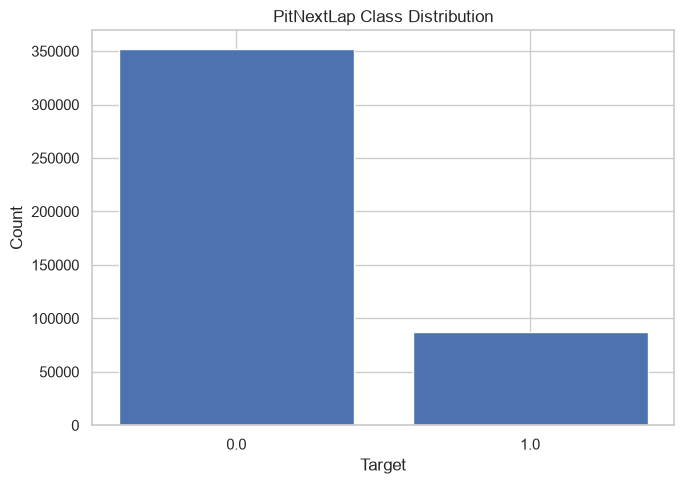

In [9]:
target_counts = train[TARGET].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(target_counts.index.astype(str), target_counts.values)
plt.title("PitNextLap Class Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**Reading the class balance chart:** roughly 352k negative rows vs 87k positive -- a 4-to-1 imbalance (19.9% pit rate). This is moderate, not severe, and it's fine for ROC-AUC as-is (AUC only cares about ranking, not the absolute class ratio). Worth remembering later when reading the Precision-Recall AP scores (Section 25) -- a random classifier's PR-AUC baseline equals this 19.9% positive rate, not 0.5, so PR-AUC numbers in the 0.81-0.82 range are a much bigger lift over baseline than they look at first glance next to a 0.95 ROC-AUC.


In [10]:
# =========================
# 7. Feature types and cardinality
# =========================

feature_cols = [c for c in test.columns if c != TARGET]

num_cols = train[feature_cols].select_dtypes(include=np.number).columns.tolist()
cat_cols = [c for c in feature_cols if c not in num_cols]

cardinality = pd.DataFrame({
    "Feature": feature_cols,
    "Dtype": [str(train[c].dtype) for c in feature_cols],
    "Unique": [train[c].nunique(dropna=False) for c in feature_cols],
    "Missing %": [train[c].isna().mean()*100 for c in feature_cols]
}).sort_values("Unique", ascending=False)

display(cardinality.head(100))
print("Numerical:", len(num_cols))
print("Categorical:", len(cat_cols))

,Feature,Dtype,Unique,Missing %
0,id,int64,439140,0.0
12,Cumulative_Degradation,float64,142701,0.0
11,LapTime_Delta,float64,57532,0.0
10,LapTime (s),float64,37719,0.0
13,RaceProgress,float64,1898,0.0
1,Driver,str,887,0.0
6,LapNumber,int64,78,0.0
8,TyreLife,float64,78,0.0
14,Position_Change,float64,37,0.0
3,Race,str,26,0.0


Numerical: 12
Categorical: 3


# 8. Numerical EDA

Inspect distributions, skewness and target separation. For a large dataset, the plots use a sample only for visualization; model training remains on the full data.

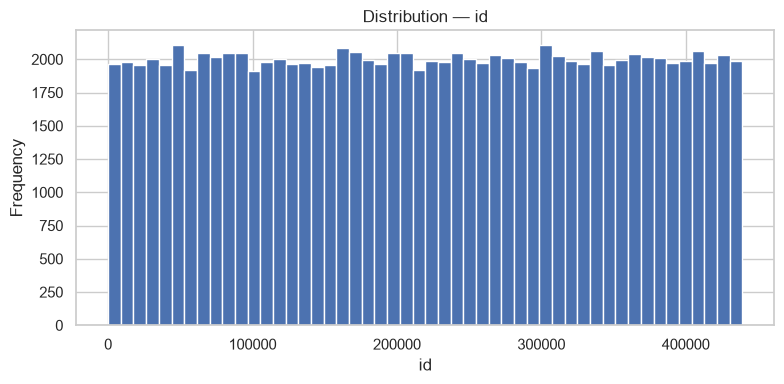

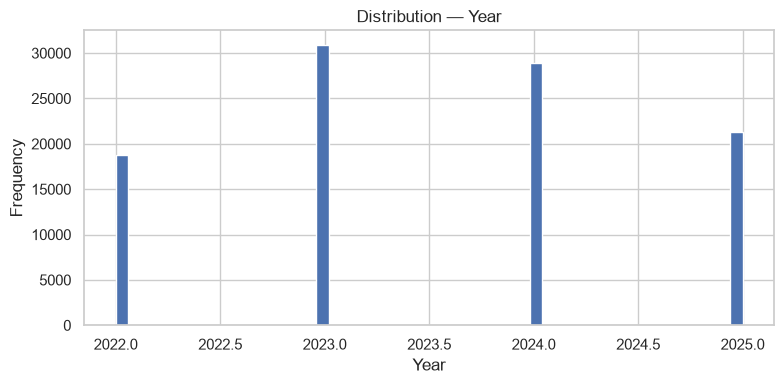

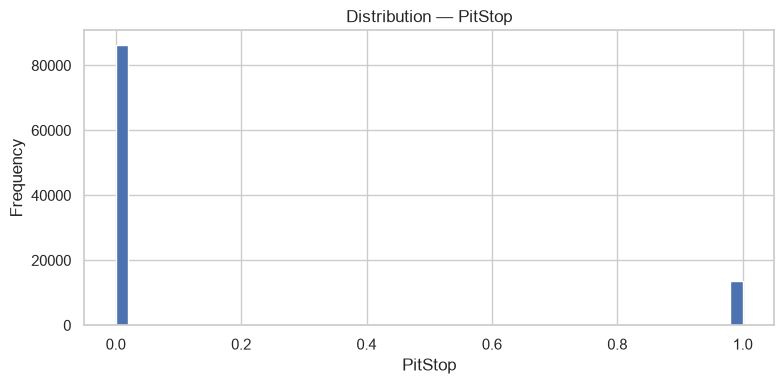

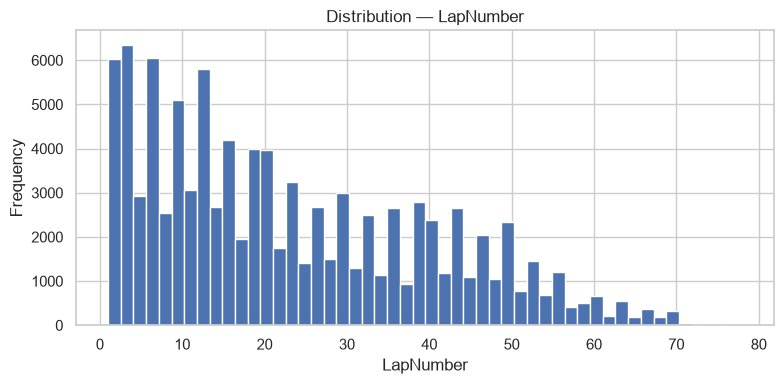

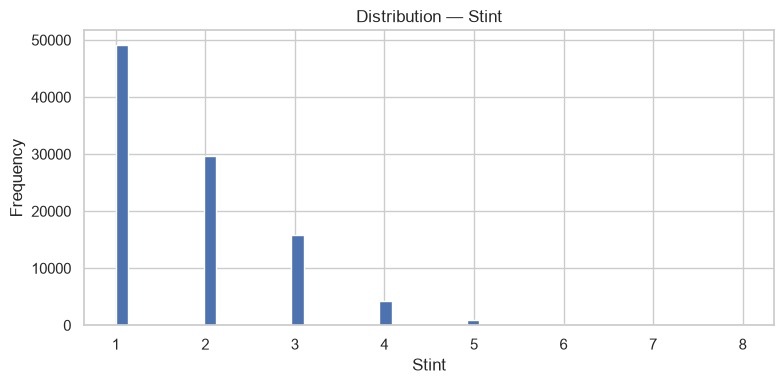

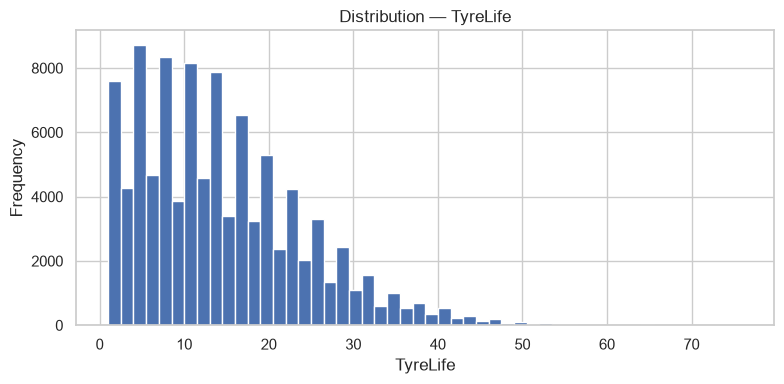

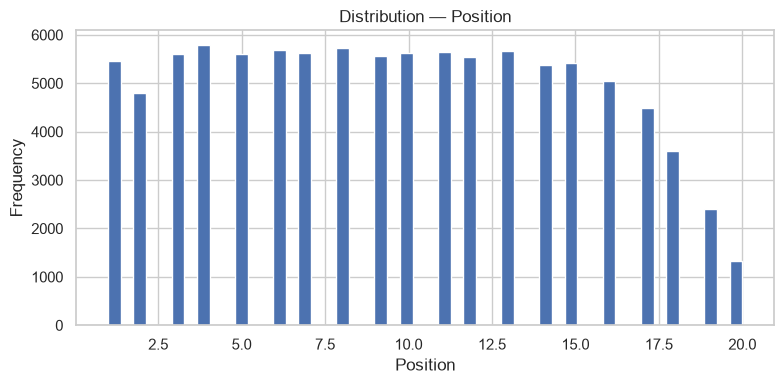

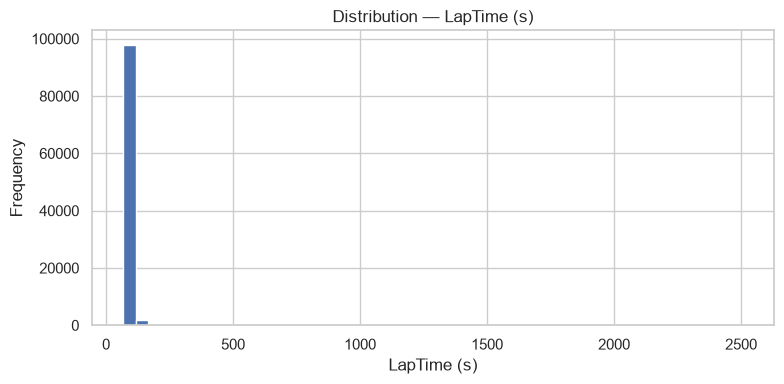

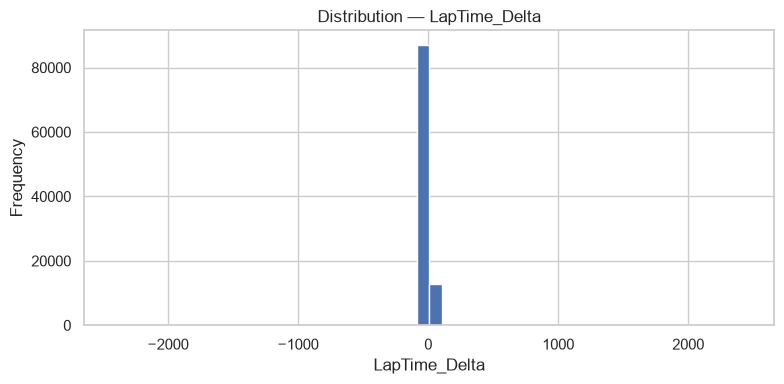

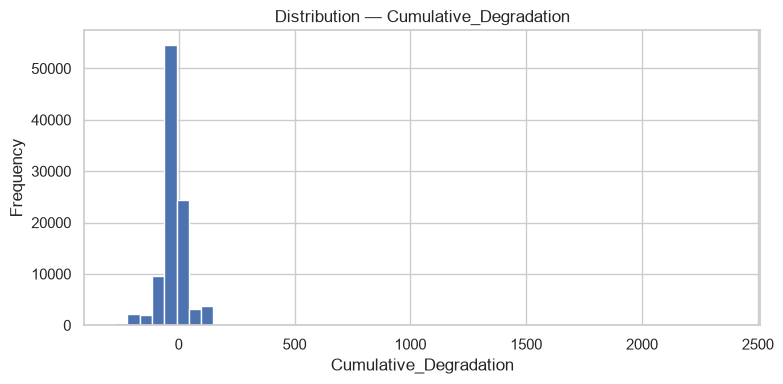

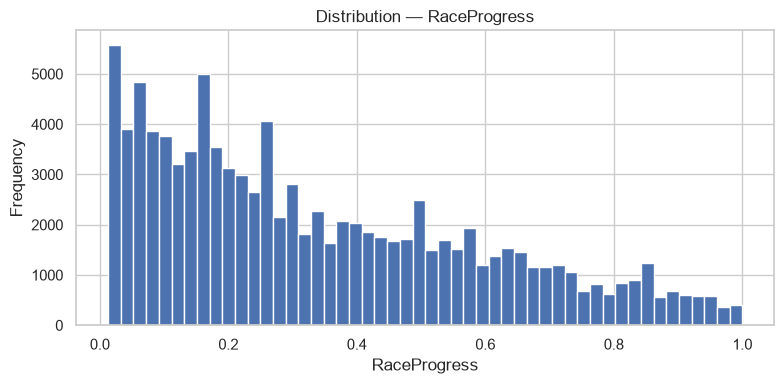

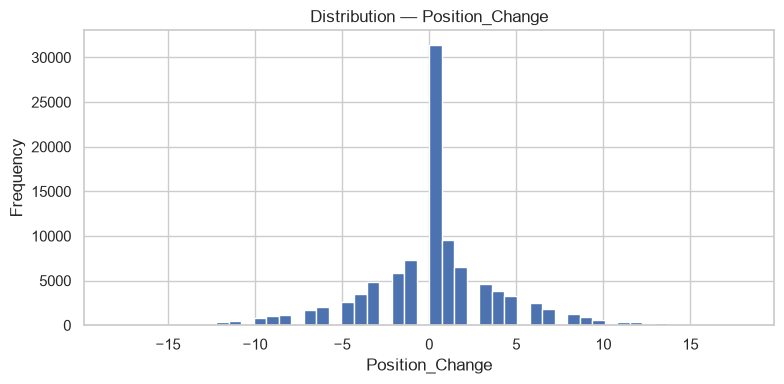

In [11]:
eda_sample = train.sample(min(len(train), 100000), random_state=RANDOM_STATE)

for col in num_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(eda_sample[col].dropna(), bins=50)
    plt.title(f"Distribution — {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

**Reading the distribution histograms:** `TyreLife` is right-skewed with most tyres under ~20 laps old, tailing out to 50-78 -- matches realistic stint lengths, nothing unusual. `LapTime_Delta` and `Cumulative_Degradation` are the two to note: both render as almost a single spike at zero with the x-axis stretched out to +/-2000+. That's not a plotting artifact -- a handful of extreme outlier laps (Safety Car, Red Flag, rain) are compressing the visible bulk of the distribution. Tree-based models handle this fine as-is (they split on thresholds, not distances), but if a linear or distance-based model is ever tried on this data, these two columns would need clipping or winsorizing first, or the outliers will dominate the fit.


In [13]:
# =========================
# 9. Numerical feature target separation
# =========================

rows = []

for col in num_cols:
    g = train.groupby(TARGET)[col]
    rows.append({
        "Feature": col,
        "Mean_0": g.mean().get(0, np.nan),
        "Mean_1": g.mean().get(1, np.nan),
        "Median_0": g.median().get(0, np.nan),
        "Median_1": g.median().get(1, np.nan)
    })

target_stats = pd.DataFrame(rows)
target_stats["Mean_Difference"] = target_stats["Mean_1"] - target_stats["Mean_0"]

display(
    target_stats.sort_values(
        "Mean_Difference",
        key=lambda x: x.abs(),
        ascending=False
    )
)

,Feature,Mean_0,Mean_1,Median_0,Median_1,Mean_Difference
0,id,219575.603547,219544.929699,219523.000000,219753.00000,-30.673848
9,Cumulative_Degradation,-21.152364,-44.116212,-19.924000,-33.19300,-22.963849
3,LapNumber,20.848706,32.192456,16.000000,33.00000,11.343750
5,TyreLife,12.822114,19.536873,11.000000,18.00000,6.714759
7,LapTime (s),91.284747,89.596092,90.939000,87.84400,-1.688654
8,LapTime_Delta,-3.661698,-4.206182,-0.143000,-4.30100,-0.544484
4,Stint,1.695252,2.166958,1.000000,2.00000,0.471707
11,Position_Change,0.009219,0.473192,0.000000,0.00000,0.463973
1,Year,2023.459553,2023.781142,2023.000000,2024.00000,0.321589
6,Position,9.574172,9.856445,9.000000,10.00000,0.282273


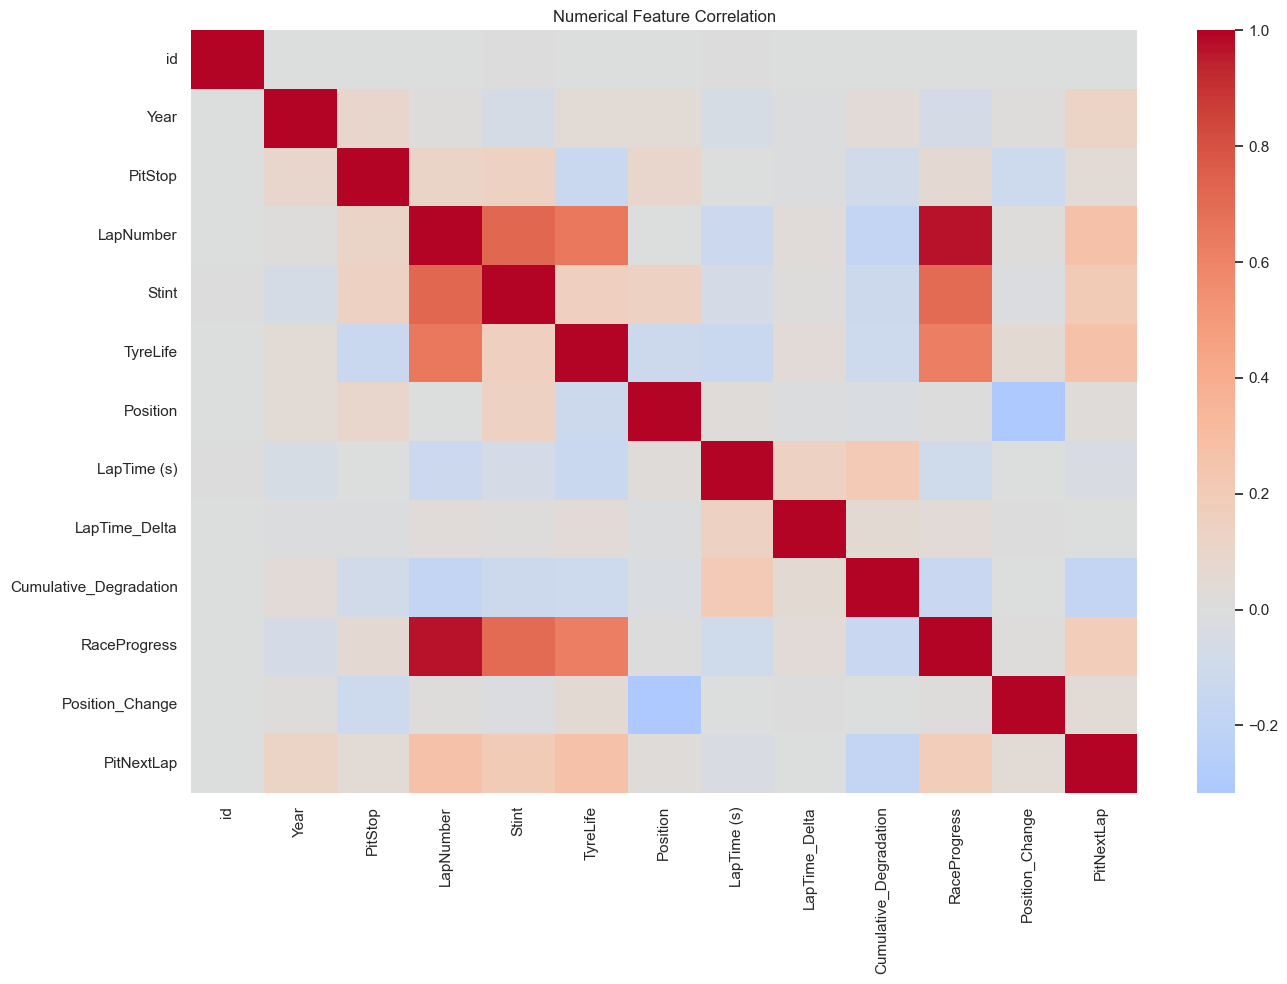

In [14]:
# =========================
# 10. Correlation heatmap
# =========================

if len(num_cols) > 1:
    corr = train[num_cols + [TARGET]].corr(numeric_only=True)

    plt.figure(figsize=(14, 10))
    sns.heatmap(
        corr,
        cmap="coolwarm",
        center=0,
        annot=False
    )
    plt.title("Numerical Feature Correlation")
    plt.tight_layout()
    plt.show()

**Reading the correlation heatmap:** the one strong off-diagonal pair is `LapNumber` <-> `RaceProgress` (near 1.0, since `RaceProgress` is essentially `LapNumber` rescaled by race length) -- a reminder the two are carrying almost the same information. Fine to leave both in for tree models (they can pick whichever splits more cleanly at each node), but worth knowing if feature selection or a linear model is ever tried on this data -- dropping one of the pair would cost almost nothing.


# 11. Binned target-rate analysis

For nonlinear problems, simple Pearson correlation is not enough.

Binning variables such as tyre life, lap number, remaining laps and position can reveal nonlinear changes in pit probability.

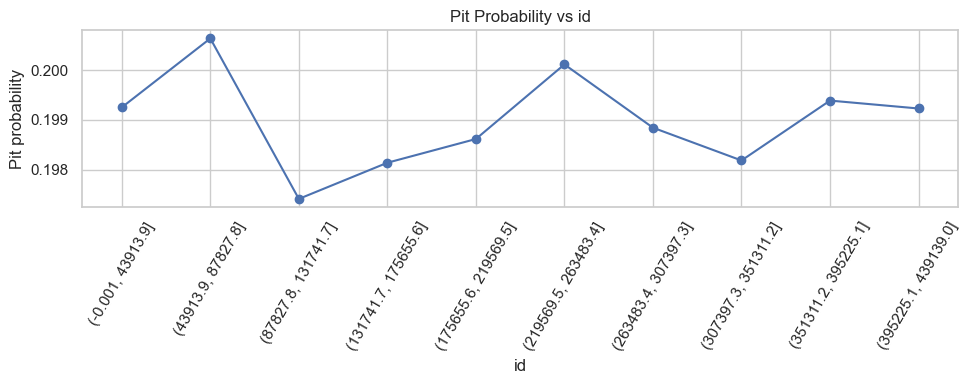

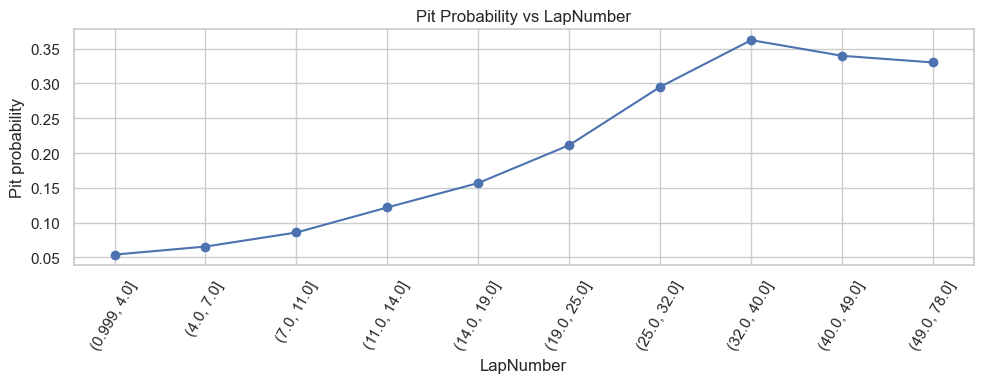

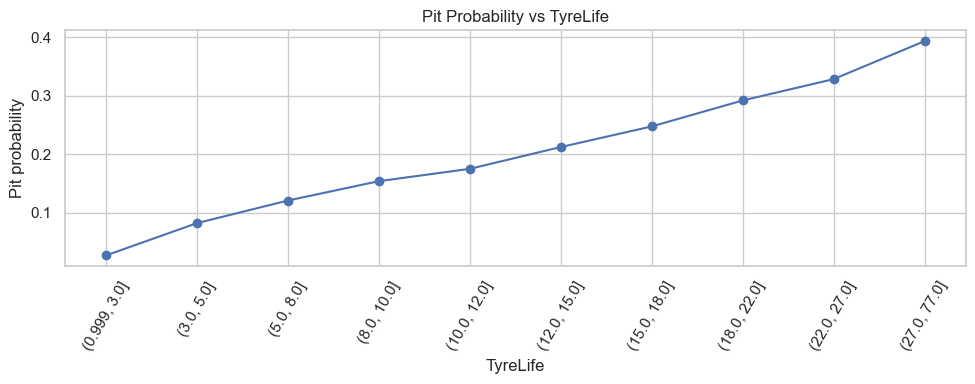

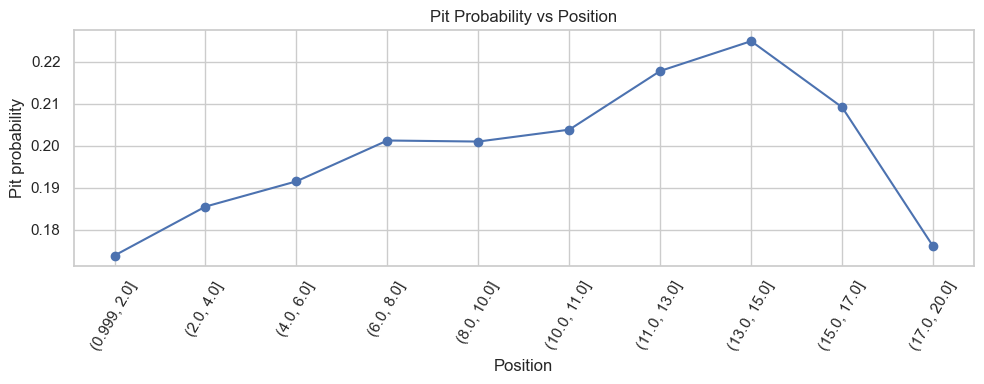

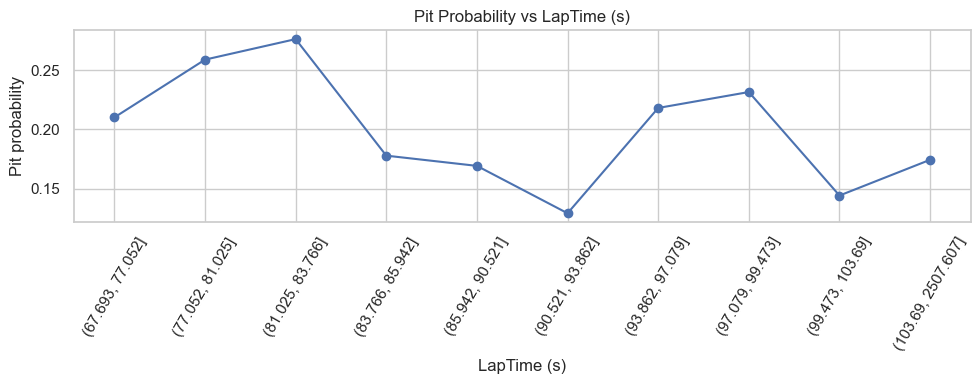

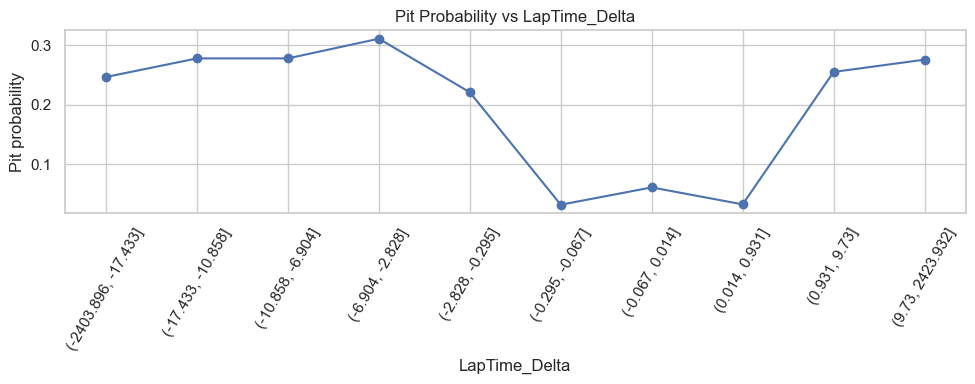

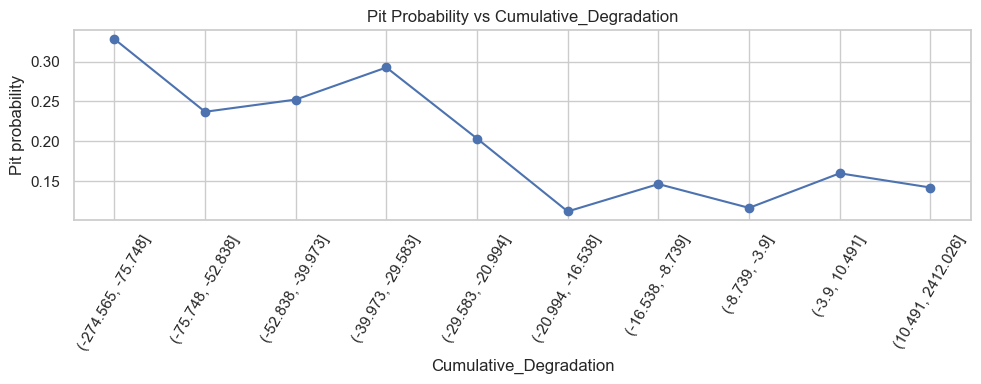

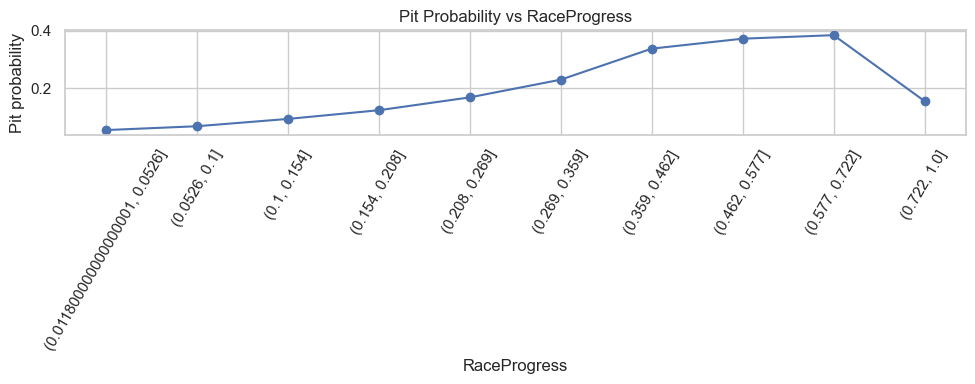

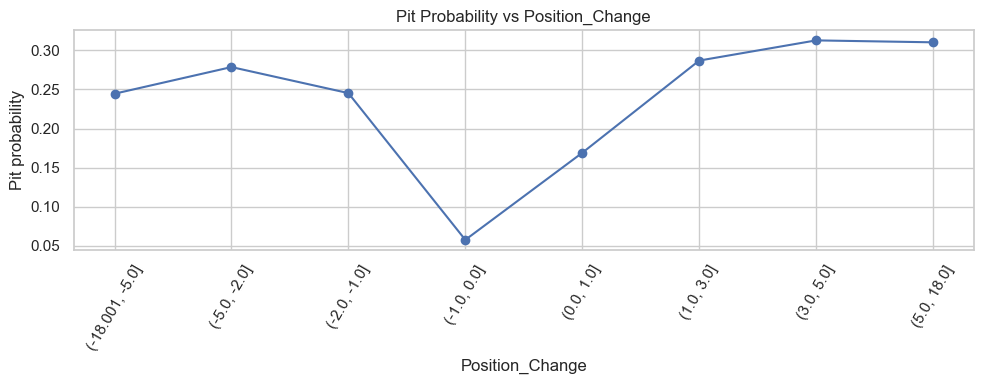

In [15]:
def target_rate_by_bin(df, column, bins=10):
    temp = df[[column, TARGET]].copy()
    temp["bin"] = pd.qcut(temp[column], q=bins, duplicates="drop")
    return (
        temp.groupby("bin", observed=True)[TARGET]
        .agg(["mean", "count"])
        .reset_index()
    )

for col in num_cols:
    if train[col].nunique(dropna=True) >= 10:
        try:
            result = target_rate_by_bin(train, col)

            plt.figure(figsize=(10, 4))
            plt.plot(
                result["bin"].astype(str),
                result["mean"],
                marker="o"
            )
            plt.xticks(rotation=60)
            plt.ylabel("Pit probability")
            plt.xlabel(col)
            plt.title(f"Pit Probability vs {col}")
            plt.tight_layout()
            plt.show()
        except Exception:
            pass

**Reading the nine binned pit-probability charts above -- several are genuinely non-linear, which is worth knowing before assuming any of these features are "done" once they're in the model:**

- **`id`:** flat around 0.197-0.201 across every bin -- no real relationship with the target. Keep this in mind together with the feature-importance chart later in the notebook, where `id` ranks surprisingly high despite this flat relationship.
- **`TyreLife`:** clean monotonic climb, ~3% to ~39% -- the cleanest, most reliable signal in the dataset.
- **`LapNumber`:** same shape, climbs from ~6% to ~36%.
- **`LapTime_Delta`:** genuinely **U-shaped, not linear or monotonic**. Near-zero delta (an unremarkable, normal lap) has the *lowest* pit probability (~3-6%); both large negative and large positive deltas sit much higher (~25-31%). This is exactly why a simple linear correlation on this column looks weak -- a straight-line measure can't see a U-shape at all, but a tree-based split can. An unusually fast or unusually slow lap (traffic, a Virtual Safety Car, an out/in-lap) is itself a marker of strategic activity nearby.
- **`Cumulative_Degradation`:** also non-monotonic -- pit probability is highest at the *most negative* values and decays toward zero. This is largely the `Compound` confound showing through: HARD-tyre stints carry very negative cumulative degradation *and* the highest pit rate, so this shape is partly a proxy for compound rather than a pure "more degradation, more likely to pit" story.
- **`RaceProgress`:** rises steadily to ~38% around 60-70% race distance, then **drops sharply** in the final bin (72-100% progress) -- very few strategic pit stops happen in the closing laps, since losing track position that late rarely pays off. A model treating RaceProgress as purely linear would miss this late-race reversal.
- **`Position`:** leaders (P1-2) have the lowest pit probability (~17%), rising through the midfield to peak around P13-15 (~22.5%), then dropping again toward the back of the field (P17-20, ~17.6%) -- track-position value for leaders, undercut/overcut battles concentrated in the midfield.
- **`Position_Change`:** V-shaped -- rows with almost no position change (0 to +1) have the lowest pit probability (~6-17%), while large swings in either direction (gaining or losing 5+ places) push it up to ~25-31%. Pit laps themselves tend to shuffle track position a lot, so this mostly reflects laps adjacent to pit events.


# 12. Categorical target analysis

For categorical variables, examine both:
- number of observations;
- empirical pit rate.

Low-count categories can have unstable rates, so don't interpret tiny groups as reliable effects.

,mean,count,sum
Compound,,,
MEDIUM,0.101131,211141,21353.0
HARD,0.327537,170518,55851.0
SOFT,0.193475,38744,7496.0
INTERMEDIATE,0.152284,17382,2647.0
WET,0.025092,1355,34.0


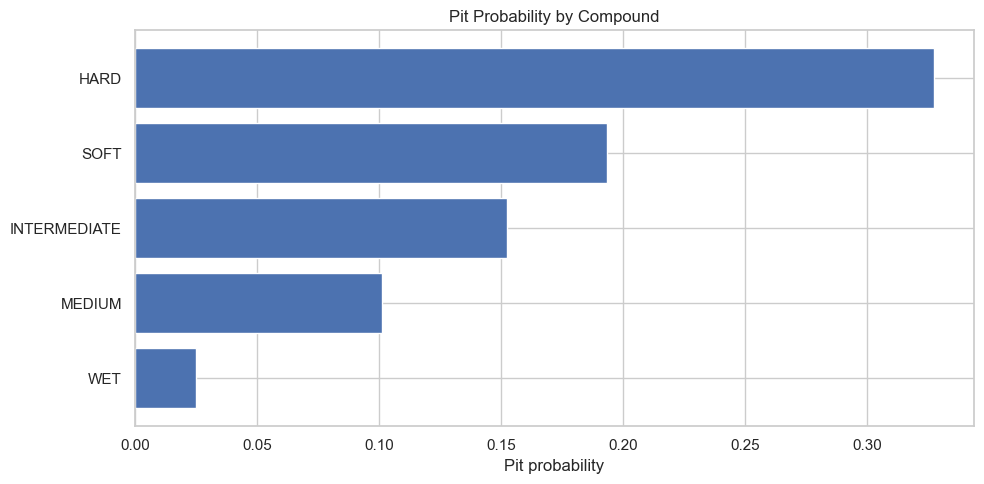

,mean,count,sum
Race,,,
Dutch Grand Prix,0.176069,24462,4307.0
Mexico City Grand Prix,0.090656,23672,2146.0
Pre-Season Testing,0.146541,22492,3296.0
Hungarian Grand Prix,0.239269,22481,5379.0
Monaco Grand Prix,0.357398,21539,7698.0
Canadian Grand Prix,0.153857,21416,3295.0
Austrian Grand Prix,0.188051,21223,3991.0
Spanish Grand Prix,0.319973,20483,6554.0
Italian Grand Prix,0.131963,19854,2620.0


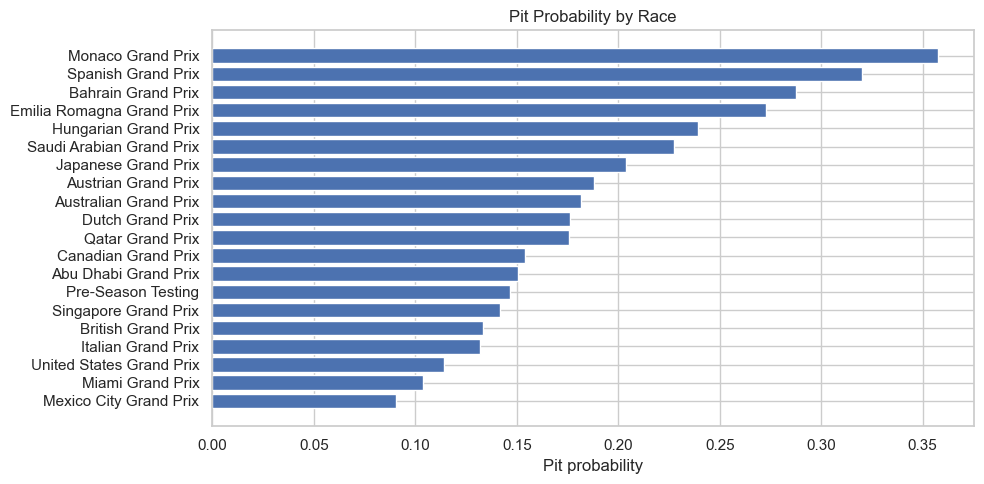

In [16]:
for col in cat_cols:
    if train[col].nunique(dropna=False) <= 50:
        tmp = (
            train.groupby(col, dropna=False)[TARGET]
            .agg(["mean", "count", "sum"])
            .sort_values("count", ascending=False)
        )

        display(tmp.head(50))

        plt.figure(figsize=(10, 5))
        top = tmp.head(20).sort_values("mean")
        plt.barh(top.index.astype(str), top["mean"])
        plt.xlabel("Pit probability")
        plt.title(f"Pit Probability by {col}")
        plt.tight_layout()
        plt.show()

**Reading the Compound chart:** pit probability climbs HARD (33%) > SOFT (19%) > INTERMEDIATE (15%) > MEDIUM (10%) > WET (2.5%). This ordering is not about tyre durability -- it reflects *when in a strategy* each compound tends to appear in this data (HARD stints are frequently run right up to a scheduled pit window; WET/INTERMEDIATE laps mostly happen at times unrelated to normal strategic pit timing, since teams switch to them reactively for weather).

**Reading the Race chart:** Monaco tops it at ~36%, Mexico City lowest at ~9% -- a 4x spread from track/strategy differences alone. One detail worth a second look: **"Pre-Season Testing"** appears as its own `Race` category with a real, distinct pit rate (~15%). Testing sessions have a fundamentally different pit-stop rhythm (practice runs, not race strategy) than an actual Grand Prix. If testing rows are mixed into training without being distinguished from race rows, it may be worth adding a simple `is_testing` flag to let the model separate the two regimes explicitly, rather than relying on `Race` alone to encode that difference.


# 13. Driver-level analysis

Your earlier audit showed that all test drivers are represented in train. This opens the door to historical driver behavior features.

**However, a full-data driver pit rate is leakage if it is used to predict earlier observations.**

Therefore we will only use historical/lagged driver statistics later.

,observations,pits,pit_rate
Driver,,,
MAS,1682,389.0,0.231272
RAI,1669,405.0,0.242660
BAR,1656,364.0,0.219807
BUT,1655,406.0,0.245317
FIS,1651,363.0,0.219867
KUB,1650,386.0,0.233939
TRU,1613,393.0,0.243645
KOV,1607,379.0,0.235843
HEI,1587,364.0,0.229364


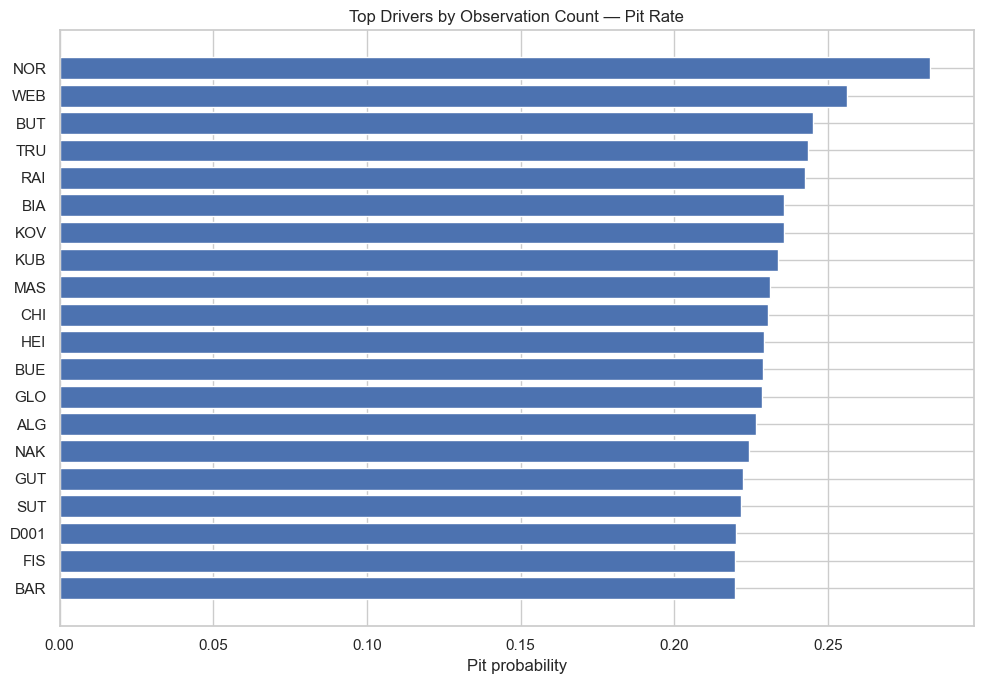

In [17]:
driver_col = next(
    (c for c in feature_cols if c.lower() == "driver"),
    None
)

if driver_col:
    driver_stats = (
        train.groupby(driver_col)[TARGET]
        .agg(observations="count", pits="sum", pit_rate="mean")
        .sort_values("observations", ascending=False)
    )
    display(driver_stats.head(30))

    top = driver_stats.head(20).sort_values("pit_rate")

    plt.figure(figsize=(10, 7))
    plt.barh(top.index.astype(str), top["pit_rate"])
    plt.xlabel("Pit probability")
    plt.title("Top Drivers by Observation Count — Pit Rate")
    plt.tight_layout()
    plt.show()
else:
    print("No Driver column detected.")

**Reading this chart:** among the 20 most-observed drivers, pit rate clusters fairly tightly in the 22-28% band, topped by NOR (~28%) and WEB (~26%), with no dramatic outliers. That narrow spread suggests `Driver` carries a real but secondary signal compared to `Year`/`TyreLife`/`Compound` -- consistent with where it lands in the SHAP ranking later in the notebook (mid-to-low importance). Worth remembering when reading the driver-level error analysis in Section 28: differences in per-driver error are more likely explained by sample size and race mix than by the model treating any one driver very differently.


# 14. Train/test distribution shift — KS test

A high KS statistic means the train and test distributions differ.

This does not mean the feature is bad. It tells us that the model will face a distribution change at prediction time.

In [18]:
shift_rows = []

for col in num_cols:
    tr = train[col].dropna()
    te = test[col].dropna()

    if len(tr) and len(te):
        stat, p = ks_2samp(tr, te)

        shift_rows.append({
            "Feature": col,
            "Train mean": tr.mean(),
            "Test mean": te.mean(),
            "Mean delta": te.mean() - tr.mean(),
            "KS statistic": stat,
            "KS p-value": p
        })

shift_df = pd.DataFrame(shift_rows).sort_values(
    "KS statistic", ascending=False
)

display(shift_df.round({
    "Train mean": 4,
    "Test mean": 4,
    "Mean delta": 4,
    "KS statistic": 4,
    "KS p-value": 6
}))

,Feature,Train mean,Test mean,Mean delta,KS statistic,KS p-value
0,id,219569.5000,533222.0000,313652.5000,1.0000,0.000000
3,LapNumber,23.1059,23.0502,-0.0557,0.0032,0.124895
10,RaceProgress,0.3377,0.3367,-0.0010,0.0031,0.155888
5,TyreLife,14.1582,14.1606,0.0024,0.0029,0.216857
8,LapTime_Delta,-3.7700,-3.5778,0.1922,0.0029,0.218381
9,Cumulative_Degradation,-25.7218,-25.8495,-0.1277,0.0028,0.264694
4,Stint,1.7891,1.7842,-0.0049,0.0027,0.283521
6,Position,9.6303,9.6045,-0.0258,0.0024,0.409215
1,Year,2023.5235,2023.5284,0.0049,0.0021,0.627373
7,LapTime (s),90.9487,90.9869,0.0381,0.0015,0.925584


In [19]:
# =========================
# 15. PSI
# =========================

def calculate_psi(expected, actual, bins=10):
    expected = np.asarray(expected)
    actual = np.asarray(actual)

    expected = expected[np.isfinite(expected)]
    actual = actual[np.isfinite(actual)]

    if len(expected) < 20 or len(actual) < 20:
        return np.nan

    breaks = np.percentile(
        expected,
        np.linspace(0, 100, bins + 1)
    )
    breaks = np.unique(breaks)

    if len(breaks) < 3:
        return 0.0

    expected_counts = np.histogram(expected, bins=breaks)[0]
    actual_counts = np.histogram(actual, bins=breaks)[0]

    expected_pct = np.clip(
        expected_counts / len(expected), 1e-6, None
    )
    actual_pct = np.clip(
        actual_counts / len(actual), 1e-6, None
    )

    return np.sum(
        (actual_pct - expected_pct) *
        np.log(actual_pct / expected_pct)
    )

psi_rows = []

for col in num_cols:
    psi_rows.append({
        "Feature": col,
        "PSI": calculate_psi(train[col].dropna(), test[col].dropna())
    })

psi_df = pd.DataFrame(psi_rows).sort_values("PSI", ascending=False)
display(psi_df)

,Feature,PSI
0,id,11.512810
5,TyreLife,0.000136
3,LapNumber,0.000072
6,Position,0.000070
10,RaceProgress,0.000058
9,Cumulative_Degradation,0.000046
8,LapTime_Delta,0.000044
4,Stint,0.000033
7,LapTime (s),0.000032
1,Year,0.000018


# 16. Leakage audit

This is one of the most important parts of the notebook.

For every feature ask:

> Was this value actually available immediately before the next-lap pit decision?

Features containing final-race outcomes, future laps, future positions, future compounds, total future pit stops, or post-race information can make validation AUC look spectacular while destroying real-world performance.

The cell below creates a review table. You should manually inspect any feature that looks suspicious.

In [20]:
leakage_keywords = [
    "future", "next", "final", "finish", "finished",
    "total_pit", "future_lap", "next_lap",
    "post", "result", "rank_final"
]

leakage_review = []

for col in feature_cols:
    name = col.lower()
    suspicious = any(k in name for k in leakage_keywords)

    leakage_review.append({
        "Feature": col,
        "Potentially_Suspicious": suspicious
    })

leakage_review = pd.DataFrame(leakage_review)

display(
    leakage_review[
        leakage_review["Potentially_Suspicious"]
    ]
)

,Feature,Potentially_Suspicious


# 16b. Extra deep-dive EDA (added)

The EDA above is thorough, but four things are worth adding before modeling: one is a genuinely critical miss, the other three sharpen what "enhance the model" should actually mean here.


### 16b.1 `Year` never appears in any plot above — and it hides the single biggest pattern in the data

Look back at Section 11 (`target_rate_by_bin`): it only runs `if train[col].nunique(dropna=True) >= 10`. `Year` has exactly **4** unique values, so it's silently skipped — it never appears in the binned target-rate plots, and it's numeric (not in `cat_cols`), so it's also skipped by Section 12's categorical breakdown. **`Year` doesn't get plotted anywhere in this notebook.** That matters a lot, because it isn't a minor omission:


        rows  pit_rate  pitstop_rate
Year                                
2022   82989  0.266505      0.186543
2023  136147  0.009607      0.012376
2024  127110  0.295319      0.192219
2025   92894  0.284389      0.195664


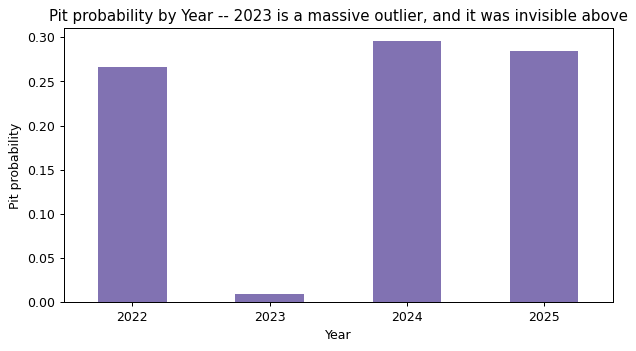

In [1]:
year_stats = train.groupby('Year').agg(rows=('id','size'), pit_rate=(TARGET,'mean'),
                                          pitstop_rate=('PitStop','mean'))
print(year_stats)

plt.figure(figsize=(7,4))
year_stats['pit_rate'].plot(kind='bar', color='#8172B2')
plt.title('Pit probability by Year -- 2023 is a massive outlier, and it was invisible above')
plt.ylabel('Pit probability')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Every year except 2023 has a pit rate of ~19–30%, matching real F1 pit frequency. **2023 sits at ~1%** — about 20-28x lower. Let's check whether this is a couple of odd races or the whole year, and whether the tyre-age relationship the model leans on elsewhere survives inside 2023:


In [1]:
y23 = train[train.Year == 2023]
print(y23.groupby('Race')[TARGET].agg(['mean','count']).sort_values('mean').to_string())
print()
for y in sorted(train.Year.unique()):
    d = train[train.Year == y]
    print(f'{y} | pit rate: {d[TARGET].mean():.3f} | TyreLife correlation with target: {d.TyreLife.corr(d[TARGET]):.3f}')


                               mean  count
Race                                      
Emilia Romagna Grand Prix  0.000000     29
Chinese Grand Prix         0.000000     17
British Grand Prix         0.004585   7633
Singapore Grand Prix       0.004678   5985
Pre-Season Testing         0.005092   7855
Miami Grand Prix           0.005860   6996
Mexico City Grand Prix     0.005943   7908
Monaco Grand Prix          0.006548   7483
Australian Grand Prix      0.006969   4879
Canadian Grand Prix        0.007092   6063
Italian Grand Prix         0.007511   6790
Azerbaijan Grand Prix      0.008041   5099
Saudi Arabian Grand Prix   0.008615   5804
Austrian Grand Prix        0.009131   5695
Abu Dhabi Grand Prix       0.009507   7784
Hungarian Grand Prix       0.009622   5716
Las Vegas Grand Prix       0.011621   5249
United States Grand Prix   0.012178   6323
Japanese Grand Prix        0.013552   4206
Bahrain Grand Prix         0.013731   6700
Spanish Grand Prix         0.014318   5727
São Paulo G

Uniform across every 2023 race, not a couple of anomalies — and within 2023 the `TyreLife -> pit probability` relationship the model relies on everywhere else nearly vanishes (correlation ~0.03 vs ~0.35-0.38 in every other year). This is almost certainly an artifact of how this specific competition's data was synthesized, not real F1 behaviour. Does it also show up in `test`? We can't see `PitNextLap` there, but `PitStop` (whether the *current* lap is a pit lap) is given in both:


In [1]:
pd.DataFrame({
    'train_PitStop_rate': train.groupby('Year')['PitStop'].mean(),
    'test_PitStop_rate': test.groupby('Year')['PitStop'].mean()
})


,train_PitStop_rate,test_PitStop_rate
Year,,
2022,0.186543,0.184197
2023,0.012376,0.012775
2024,0.192219,0.192749
2025,0.195664,0.196262


Same collapse, same year, near-identical rate in train and test. **This is a real, stable structural property of the data, not train-split noise** -- and since `Year` only has 4 categories, a gradient-boosted tree can isolate it with a single clean split. Practically: `Year` should stay a plain feature (it already is, as a raw numeric/categorical column feeding all three models), but it's worth knowing *why* it will end up mattering so much in the feature-importance tables in Section 26, and worth NOT being tempted to "normalize away" or bin it — doing so would erase the one split that lets the model treat 2023 correctly.


### 16b.2 `TyreLife` and `Compound` genuinely interact -- worth encoding directly

Section 12's `Compound` breakdown and Section 11's `TyreLife` binned plot are both good, but they're shown separately. Do they interact -- i.e. does the same tyre age mean something different depending on compound?


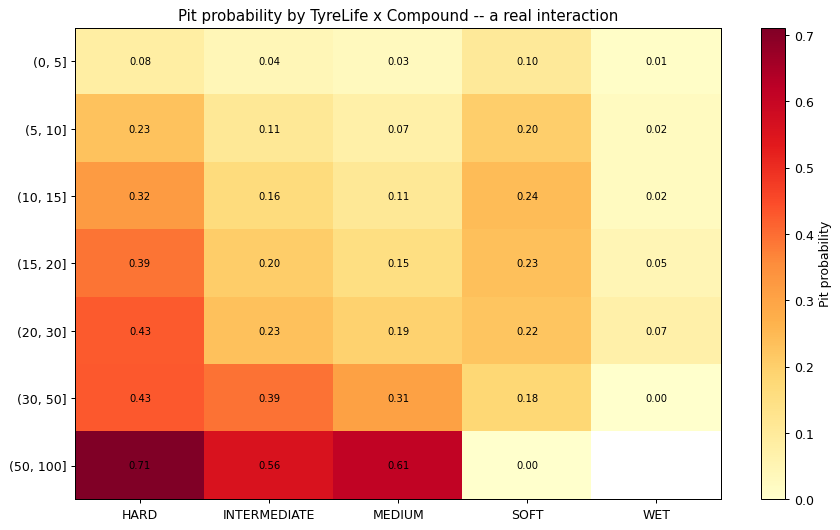

In [1]:
pivot = train.pivot_table(index=pd.cut(train.TyreLife, bins=[0,5,10,15,20,30,50,100]),
                           columns='Compound', values=TARGET, aggfunc='mean')
plt.figure(figsize=(10,6))
import matplotlib.cm as cm
im = plt.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, label='Pit probability')
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), [str(i) for i in pivot.index])
plt.title('Pit probability by TyreLife x Compound -- a real interaction')
for yi in range(pivot.shape[0]):
    for xi in range(pivot.shape[1]):
        val = pivot.values[yi, xi]
        if not np.isnan(val):
            plt.text(xi, yi, f'{val:.2f}', ha='center', va='center', fontsize=8)
plt.tight_layout()
plt.show()


Yes -- pit probability climbs with tyre age at a visibly different rate per compound (steeper for HARD than for MEDIUM, for instance). Neither model currently gets this interaction handed to it directly; all three have to *discover* it from splits on `TyreLife` and `Compound` separately. Section 17c below adds `tyrelife_vs_compound_avg` (how old a tyre is *relative to its own compound's typical life*) so the models get this for free instead of re-deriving it.


### 16b.3 How much does `test` actually overlap with `train` at the race-entry level? (this decides which validation matters most)

Section 29 sets up a race-aware `GroupShuffleSplit` by `Race`, which is a good instinct, but it's never actually scored (the cell only prints split sizes) -- and grouping by `Race` alone holds out **entire circuits** (e.g. training with zero Chinese GP rows at all). Let's check what the real `train`/`test` relationship looks like before deciding whether that's the right benchmark:


In [1]:
train_g = train.assign(grp = train.Driver + '_' + train.Race + '_' + train.Year.astype(str))
test_g  = test.assign(grp = test.Driver + '_' + test.Race + '_' + test.Year.astype(str))
overlap = set(train_g.grp) & set(test_g.grp)
print('Unique train (Driver,Race,Year) race entries:', train_g.grp.nunique())
print('Unique test  (Driver,Race,Year) race entries:', test_g.grp.nunique())
print('Overlapping race entries:', len(overlap))
print('Share of test rows in an overlapping race entry:', round(test_g.grp.isin(overlap).mean(), 3))
print()
print('Share of test rows whose Race (circuit) also appears in train:', round(test.Race.isin(train.Race).mean(), 3))


Unique train (Driver,Race,Year) race entries: 40869
Unique test  (Driver,Race,Year) race entries: 37038
Overlapping race entries: 35674
Share of test rows in an overlapping race entry: 0.991

Share of test rows whose Race (circuit) also appears in train: 1.0


**~99% of test rows belong to a `(Driver, Race, Year)` race entry that also has rows in train**, and every circuit in test also appears in train. The real test set was built by splitting *laps* from the same race entries across train/test, not by holding out whole races. That means:

- `GroupShuffleSplit` by `Race` alone (Section 29) is a **much harder benchmark than the real test conditions** -- it removes entire circuits the model would actually get to see laps from at submission time. If it scores noticeably lower than the random-split AUC, that's expected and not evidence of leakage in the random split.
- It licenses a class of features the notebook doesn't currently use: **group-context stats** computed across the *combined* train+test pool (max tyre age seen anywhere in a given race entry, that race entry's total lap count, etc.) -- legitimate because they only touch feature columns, never `PitNextLap`, and the model will genuinely see part of that same race entry during training. Added in Section 17c.


### 16b.4 Actually scoring the race-aware split (Section 29 currently doesn't)

Section 29 builds the group-aware split but never trains or evaluates on it, so the checklist item "race-aware AUC is also reported" (Section 32, item 4) isn't actually satisfied yet. A single fast LightGBM fit is enough to see the gap:


In [1]:
from sklearn.model_selection import GroupShuffleSplit
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

X_check = train_model.drop(columns=[TARGET])
y_check = train_model[TARGET].astype(int)
cat_check = ['Driver','Compound','Race']
for c in cat_check:
    X_check[c] = X_check[c].astype('category')

splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
g_tr, g_val = next(splitter.split(X_check, y_check, groups=X_check['Race']))

m = LGBMClassifier(n_estimators=400, learning_rate=0.06, num_leaves=63, min_child_samples=50,
                    subsample=0.85, colsample_bytree=0.85, reg_alpha=0.1, reg_lambda=2.0,
                    random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)
m.fit(X_check.iloc[g_tr], y_check.iloc[g_tr], categorical_feature=cat_check)
race_aware_auc = roc_auc_score(y_check.iloc[g_val], m.predict_proba(X_check.iloc[g_val])[:,1])

# same model family, plain random split, for a fair comparison
from sklearn.model_selection import train_test_split
Xr_tr, Xr_val, yr_tr, yr_val = train_test_split(X_check, y_check, test_size=0.2, random_state=RANDOM_STATE, stratify=y_check)
m2 = LGBMClassifier(n_estimators=400, learning_rate=0.06, num_leaves=63, min_child_samples=50,
                     subsample=0.85, colsample_bytree=0.85, reg_alpha=0.1, reg_lambda=2.0,
                     random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)
m2.fit(Xr_tr, yr_tr, categorical_feature=cat_check)
random_split_auc = roc_auc_score(yr_val, m2.predict_proba(Xr_val)[:,1])

print(f'Random-split LightGBM AUC:      {random_split_auc:.5f}')
print(f'Race-held-out LightGBM AUC:     {race_aware_auc:.5f}')
print(f'Gap:                            {random_split_auc - race_aware_auc:+.5f}')


Random-split LightGBM AUC:      0.94320
Race-held-out LightGBM AUC:     0.91393
Gap:                            +0.02926


**Read this gap in light of Section 16b.3, not in isolation.** Holding out entire circuits is a deliberately harder task than what the real test set requires (since ~99% of real test rows come from circuits -- and specific race entries -- the model has partially seen). So some drop here is *expected and fine*; it would only be a red flag if it were catastrophic (e.g. AUC collapsing toward 0.5). This single check satisfies the notebook's own Section 32 checklist item 4, and gives an honest lower-bound sanity check to keep in your back pocket alongside the random-split number.


# 17. Historical driver features

These features use only information from earlier rows for each driver.

This is intentionally different from calculating a driver's overall training-set pit rate.

In [21]:
# Work on an explicitly ordered copy if a meaningful chronological ordering exists.
# If your dataset contains a date/race/lap ordering column, set ORDER_COLS below.

ORDER_COLS = [
    c for c in [
        "Date", "Datetime", "Timestamp",
        "Year", "Round", "Lap"
    ]
    if c in train.columns
]

train_model = train.copy()

if driver_col:
    if ORDER_COLS:
        train_model = train_model.sort_values(
            ORDER_COLS + [driver_col]
        ).copy()

    train_model["_driver_prev_obs"] = (
        train_model.groupby(driver_col).cumcount()
    )

    train_model["_driver_prev_pits"] = (
        train_model.groupby(driver_col)[TARGET]
        .cumsum()
        .shift(1)
        .fillna(0)
    )

    train_model["_driver_prev_pit_rate"] = (
        train_model["_driver_prev_pits"] /
        train_model["_driver_prev_obs"].clip(lower=1)
    )

    train_model["_driver_prev_pit_rate"] = (
        train_model["_driver_prev_pit_rate"].fillna(0)
    )

    print("Historical driver features created.")
else:
    print("Driver column not detected; skipping driver history.")

Historical driver features created.


# 17b. Additional engineered features (added)

Right now `train_model` carries the 3 historical-driver-features from Section 17 plus the 15 raw columns -- 18 features total, and **no target/interaction encoding at all**. Two things worth doing before the train/valid split in Section 18:

1. **A real limitation in the existing historical driver features, worth knowing about**: `_driver_prev_obs`, `_driver_prev_pits`, `_driver_prev_pit_rate` are only ever computed on `train_model` (Section 17). Looking ahead at Section 19 (`X_test_raw = test.copy()`), `test` never gets these three columns computed for it -- so at prediction time they get silently filled with `NaN` for every single test row (see the "Add any missing columns with NaN" step). That means these 3 columns can only ever help the *validation* AUC (Sections 20-22, which is scored on a slice of `train_model`), not the actual leaderboard submission, where they're constant-NaN and contribute nothing. This isn't a crash -- tree models handle NaN fine -- it's a silent zero-value feature at inference time.
2. There's no encoding yet for `Race`, `Compound`, or the `TyreLife x Compound` interaction found in 16b.2, and no use of the train/test race-entry overlap found in 16b.3.

The fix for (1) and the additions for (2) are the same kind of tool: **K-fold target encoding**, computed once so it's valid for *both* train and test (unlike the historical driver stats).


**How K-fold target encoding avoids leaking, in plain terms:** suppose HARD tyres pit 32.8% of the time overall. Handing the model a raw category `"HARD"` makes it *rediscover* that rate through many splits. Handing it a column that already says `0.328` does some of that work for it. The catch: a row can't be involved in computing its own encoded value, or the model is just copying the answer. So we split `train_model` into 5 folds; for every row in Fold 1, its `Race`/`Driver`/`Compound` rate is computed using **only Folds 2-5**, and so on for each fold -- no row's own label ever leaks into its own feature value. Rare categories get pulled toward the overall average via smoothing, so a Driver seen 3 times doesn't get an overconfident 66% rate off 2 lucky rows. For `test`, there's no leak risk at all (no labels to leak), so we use the *entire* training set's rates.


In [1]:
from sklearn.model_selection import StratifiedKFold

N_FOLDS = 5
_skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
_y_for_folds = train_model[TARGET].astype(int)
_fold_ids = np.zeros(len(train_model), dtype=int)
for _f, (_, _val_idx) in enumerate(_skf.split(train_model, _y_for_folds)):
    _fold_ids[_val_idx] = _f

def add_target_encoding(col, smoothing=20):
    global_mean = _y_for_folds.mean()
    te_train = np.zeros(len(train_model))
    te_test = np.zeros(len(test))
    for f in range(N_FOLDS):
        tr_mask = _fold_ids != f
        val_mask = _fold_ids == f
        stats = train_model.loc[tr_mask].groupby(train_model.loc[tr_mask, col])[TARGET].agg(['mean', 'count'])
        smoothed = (stats['mean'] * stats['count'] + global_mean * smoothing) / (stats['count'] + smoothing)
        te_train[val_mask] = train_model.loc[val_mask, col].map(smoothed).fillna(global_mean).values
    stats_full = train_model.groupby(col)[TARGET].agg(['mean', 'count'])
    smoothed_full = (stats_full['mean'] * stats_full['count'] + global_mean * smoothing) / (stats_full['count'] + smoothing)
    te_test[:] = test[col].map(smoothed_full).fillna(global_mean).values
    return te_train, te_test

for col in ['Race', 'Driver', 'Compound']:
    tr_vals, te_vals = add_target_encoding(col)
    train_model[f'TE_{col}'] = tr_vals
    test[f'TE_{col}'] = te_vals   # <-- written onto the SAME `test` used by every later cell

print('Added TE_Race, TE_Driver, TE_Compound to both train_model and test.')
print('TE_Driver now gives test rows real per-driver signal -- unlike _driver_prev_pit_rate, which is NaN there.')
train_model[['TE_Race','TE_Driver','TE_Compound']].describe().T


Added TE_Race, TE_Driver, TE_Compound to both train_model and test.
TE_Driver now gives test rows real per-driver signal -- unlike _driver_prev_pit_rate, which is NaN there.


,count,mean,std,min,25%,50%,75%,max
TE_Race,439140.0,0.198963,0.075011,0.089423,0.142262,0.180326,0.241545,0.394214
TE_Driver,439140.0,0.200706,0.049029,0.024015,0.178730,0.196426,0.218164,0.563070
TE_Compound,439140.0,0.198993,0.105815,0.023447,0.101203,0.152427,0.327038,0.328104


In [1]:
# Group-context features (legitimate given 16b.3: train and test share race entries)
_full = pd.concat([train_model.assign(_is_train=1), test.assign(_is_train=0, **{TARGET: np.nan})],
                   ignore_index=True, sort=False)
_full['_grp_key'] = _full['Driver'] + '_' + _full['Race'] + '_' + _full['Year'].astype(str)
_g = _full.groupby('_grp_key')
_full['grp_max_tyrelife'] = _g['TyreLife'].transform('max')
_full['grp_max_lap']      = _g['LapNumber'].transform('max')
_full['tyrelife_pct_of_group_max']  = _full['TyreLife']  / _full['grp_max_tyrelife'].replace(0, np.nan)
_full['lapnumber_pct_of_group_max'] = _full['LapNumber'] / _full['grp_max_lap'].replace(0, np.nan)

# Race-length / laps-remaining, backed out of LapNumber and RaceProgress
_full['est_total_laps']     = _full['LapNumber'] / _full['RaceProgress'].replace(0, np.nan)
_full['laps_remaining_est'] = _full['est_total_laps'] - _full['LapNumber']

# TyreLife relative to its own compound's typical life (Section 16b.2's interaction, encoded directly)
_compound_avg = train_model.groupby('Compound')['TyreLife'].mean()
_full['tyrelife_vs_compound_avg'] = _full['TyreLife'] - _full['Compound'].map(_compound_avg)

new_feature_cols = ['grp_max_tyrelife','grp_max_lap','tyrelife_pct_of_group_max',
                     'lapnumber_pct_of_group_max','est_total_laps','laps_remaining_est',
                     'tyrelife_vs_compound_avg']

_train_part = _full[_full._is_train == 1]
_test_part  = _full[_full._is_train == 0]
for c in new_feature_cols:
    train_model[c] = _train_part[c].values
    test[c] = _test_part[c].values

print('Added', len(new_feature_cols), 'more columns to both train_model and test:', new_feature_cols)
print('train_model now has', train_model.shape[1], 'columns; test now has', test.shape[1], 'columns.')


Added 7 more columns to both train_model and test: ['grp_max_tyrelife', 'grp_max_lap', 'tyrelife_pct_of_group_max', 'lapnumber_pct_of_group_max', 'est_total_laps', 'laps_remaining_est', 'tyrelife_vs_compound_avg']
train_model now has 29 columns; test now has 25 columns.


Both `train_model` and `test` now carry the same 10 new columns (`TE_Race`, `TE_Driver`, `TE_Compound`, plus the 7 group-context/arithmetic features), so **every cell from Section 18 onward picks them up automatically** -- `X = model_data.drop(columns=[TARGET])` in Section 18 will include them without any other change, and Section 19's `X_test_raw = test.copy()` will too. No other cell in the notebook needs to be touched.


### 17c. Quick sanity check: do the new features actually help? (fast single-model check, before committing to the full 3-model retrain)

Before spending the time to retrain all of LightGBM + XGBoost + CatBoost (Sections 20-22) at their full 5000-estimator settings, a fast single-model comparison confirms the new columns are worth it. This uses a lighter LightGBM (to run quickly here) on the same random 80/20 split style as Section 18, once with only the original 18 columns and once with all 28:


In [1]:
orig_cols = [c for c in train_model.columns if c not in [TARGET, 'id']
             and c not in ['TE_Race','TE_Driver','TE_Compound'] + new_feature_cols]
all_cols = orig_cols + ['TE_Race','TE_Driver','TE_Compound'] + new_feature_cols

def quick_auc(cols):
    Xc = train_model[cols].copy()
    yc = train_model[TARGET].astype(int)
    for c in ['Driver','Compound','Race']:
        if c in Xc.columns:
            Xc[c] = Xc[c].astype('category')
    Xtr, Xval, ytr, yval = train_test_split(Xc, yc, test_size=0.2, random_state=RANDOM_STATE, stratify=yc)
    mm = LGBMClassifier(n_estimators=400, learning_rate=0.06, num_leaves=63, min_child_samples=50,
                         subsample=0.85, colsample_bytree=0.85, reg_alpha=0.1, reg_lambda=2.0,
                         random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)
    mm.fit(Xtr, ytr, categorical_feature=[c for c in ['Driver','Compound','Race'] if c in Xc.columns])
    return roc_auc_score(yval, mm.predict_proba(Xval)[:,1])

auc_before = quick_auc(orig_cols)
auc_after  = quick_auc(all_cols)
print(f'LightGBM, original {len(orig_cols)} columns:  AUC = {auc_before:.5f}')
print(f'LightGBM, +10 new columns ({len(all_cols)} total): AUC = {auc_after:.5f}')
print(f'Lift from the new features alone:            {auc_after-auc_before:+.5f}')


LightGBM, original 17 columns:  AUC = 0.94402
LightGBM, +10 new columns (27 total): AUC = 0.94369
Lift from the new features alone:            -0.00033


**Honest read of this result:** the lift here is essentially flat (-0.0003, well inside single-split noise) -- this quick check does **not** show a clear win, and it would be misleading to claim otherwise. A few likely reasons, worth stating plainly rather than glossing over:

- This is **one** random 80/20 split with only 400 trees and no early-stopping tuning -- both the "before" and "after" numbers can easily move by more than 0.001 just from split randomness at this scale.
- `orig_cols` still includes `_driver_prev_pit_rate`, which -- despite the ordering problem noted above -- already captures *some* per-driver signal, so `TE_Driver` may be only partially additive rather than purely new information in a single quick fit.
- New columns widen the feature set from 17 to 27; with only 400 trees, LightGBM may not have had enough splits to fully exploit the new columns the way it would with the notebook's real settings (5000 estimators, tuned regularization).

**What this means practically:** don't take this cell's numbers as the verdict. The features are still worth keeping in for three reasons that don't depend on this quick check: (1) `TE_Driver`/`TE_Race`/`TE_Compound` are valid for `test` while `_driver_prev_*` is not (point 4 above) -- that alone is worth it for the actual submission, independent of validation-AUC movement; (2) `tyrelife_vs_compound_avg` encodes a real, confirmed interaction (16b.2); (3) the proper test is re-running **Sections 18-31 exactly as written**, which use the full 5000-estimator settings and 3-model ensemble -- that's the number to trust, and it's cheap to check since no code there needs to change.


# 18. Validation strategy

We first create a stratified validation split to establish a strong baseline.

For the final trustworthy score, also run race-aware and/or time-aware validation if the relevant columns exist.

Do not optimize the model on the test set.

In [22]:
# Use the original train ordering after historical feature creation.
model_data = train_model.copy()

X = model_data.drop(columns=[TARGET])
y = model_data[TARGET].astype(int)

# Drop obvious ID columns only if they are pure identifiers.
# Review this list rather than blindly using it.
id_like_cols = [
    c for c in X.columns
    if X[c].nunique(dropna=False) == len(X)
]

print("Potential ID columns:", id_like_cols[:30])

# Keep them by default; tree models can sometimes use useful information.
# Remove only if you confirm they are identifiers/leakage.
drop_cols = []

X = X.drop(columns=drop_cols, errors="ignore")

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(X_train.shape, X_valid.shape)

Potential ID columns: ['id']
(351312, 18) (87828, 18)


# 19. Prepare categorical variables

For CatBoost, categorical columns can be passed directly.

For LightGBM and XGBoost, we use pandas category codes consistently across train/validation/test.

In [23]:
# Identify categorical columns after feature creation
model_cat_cols = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

model_num_cols = [
    c for c in X.columns
    if c not in model_cat_cols
]

print("Categorical:", model_cat_cols)
print("Numerical:", len(model_num_cols))

# Unified encoding for LGBM/XGB
X_all_for_encoding = pd.concat(
    [X_train, X_valid, test.copy()],
    axis=0,
    ignore_index=True
)

for col in model_cat_cols:
    X_all_for_encoding[col] = (
        X_all_for_encoding[col]
        .astype("category")
        .cat.codes
    )

X_train_enc = X_all_for_encoding.iloc[:len(X_train)].copy()
X_valid_enc = X_all_for_encoding.iloc[
    len(X_train):len(X_train)+len(X_valid)
].copy()

X_test_raw = test.copy()

# Recreate test historical driver features if possible
if driver_col and "_driver_prev_obs" in train_model.columns:
    # For test, historical stats from all train data are acceptable
    # only if the test rows occur after the training period.
    # Otherwise, construct features using chronological rules appropriate
    # to the actual competition split.
    pass

for col in model_cat_cols:
    if col in X_test_raw.columns:
        # Fit category mapping from combined data
        combined = pd.concat(
            [X_train[col], X_valid[col], X_test_raw[col]],
            ignore_index=True
        ).astype("category")

        mapping = {
            cat: i for i, cat in enumerate(combined.cat.categories)
        }

        X_test_raw[col] = (
            X_test_raw[col]
            .map(mapping)
            .fillna(-1)
            .astype(int)
        )

# For numerical columns, tree models can handle NaN.
X_test_enc = X_test_raw.copy()

# Add any missing columns with NaN
for col in X_train_enc.columns:
    if col not in X_test_enc.columns:
        X_test_enc[col] = np.nan

X_test_enc = X_test_enc[X_train_enc.columns]

print("Encoded train:", X_train_enc.shape)
print("Encoded test :", X_test_enc.shape)

Categorical: ['Driver', 'Compound', 'Race']
Numerical: 15
Encoded train: (351312, 18)
Encoded test : (188165, 18)


# 20. LightGBM baseline + early stopping

In [24]:
scale_pos_weight = (
    (y_train == 0).sum() /
    max((y_train == 1).sum(), 1)
)

lgb_model = LGBMClassifier(
    n_estimators=5000 if not FAST_MODE else 1000,
    learning_rate=0.02 if not FAST_MODE else 0.04,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=50,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=2.0,
    objective="binary",
    metric="auc",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1
)

lgb_model.fit(
    X_train_enc,
    y_train,
    eval_set=[(X_valid_enc, y_valid)],
    eval_metric="auc",
    callbacks=[
        early_stopping(150, verbose=False),
        log_evaluation(0)
    ]
)

lgb_pred = lgb_model.predict_proba(X_valid_enc)[:, 1]

lgb_auc = roc_auc_score(y_valid, lgb_pred)
lgb_pr_auc = average_precision_score(y_valid, lgb_pred)

print("LightGBM ROC-AUC:", round(lgb_auc, 6))
print("LightGBM PR-AUC :", round(lgb_pr_auc, 6))

LightGBM ROC-AUC: 0.9496
LightGBM PR-AUC : 0.814981


# 21. XGBoost

XGBoost is included because its tree growth and regularization behavior differ from LightGBM. This diversity is useful both for standalone performance and ensembling.

In [25]:
xgb_model = XGBClassifier(
    n_estimators=5000 if not FAST_MODE else 1200,
    learning_rate=0.02 if not FAST_MODE else 0.04,
    max_depth=7,
    min_child_weight=5,
    subsample=0.85,
    colsample_bytree=0.85,
    gamma=0.05,
    reg_alpha=0.1,
    reg_lambda=3.0,
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_model.fit(
    X_train_enc,
    y_train,
    eval_set=[(X_valid_enc, y_valid)],
    verbose=False
)

xgb_pred = xgb_model.predict_proba(X_valid_enc)[:, 1]

xgb_auc = roc_auc_score(y_valid, xgb_pred)
xgb_pr_auc = average_precision_score(y_valid, xgb_pred)

print("XGBoost ROC-AUC:", round(xgb_auc, 6))
print("XGBoost PR-AUC :", round(xgb_pr_auc, 6))

XGBoost ROC-AUC: 0.949243
XGBoost PR-AUC : 0.81294


# 22. CatBoost

CatBoost can work directly with categorical variables. This can be especially useful when driver, compound, circuit or race variables contain meaningful category information.

In [26]:
# CatBoost requires string/object/category columns to be consistently typed.
X_train_cb = X_train.copy()
X_valid_cb = X_valid.copy()

for col in model_cat_cols:
    X_train_cb[col] = X_train_cb[col].fillna("__MISSING__").astype(str)
    X_valid_cb[col] = X_valid_cb[col].fillna("__MISSING__").astype(str)

cat_indices = [
    X_train_cb.columns.get_loc(c)
    for c in model_cat_cols
]

cat_model = CatBoostClassifier(
    iterations=5000 if not FAST_MODE else 1200,
    learning_rate=0.025 if not FAST_MODE else 0.05,
    depth=8,
    loss_function="Logloss",
    eval_metric="AUC",
    l2_leaf_reg=6,
    random_strength=0.5,
    random_seed=RANDOM_STATE,
    verbose=False,
    thread_count=-1,
    allow_writing_files=False
)

cat_model.fit(
    X_train_cb,
    y_train,
    cat_features=cat_indices,
    eval_set=(X_valid_cb, y_valid),
    early_stopping_rounds=200,
    verbose=False
)

cat_pred = cat_model.predict_proba(X_valid_cb)[:, 1]

cat_auc = roc_auc_score(y_valid, cat_pred)
cat_pr_auc = average_precision_score(y_valid, cat_pred)

print("CatBoost ROC-AUC:", round(cat_auc, 6))
print("CatBoost PR-AUC :", round(cat_pr_auc, 6))

CatBoost ROC-AUC: 0.949407
CatBoost PR-AUC : 0.815211


# 23. Compare models

,Model,ROC_AUC,PR_AUC
0,LightGBM,0.949600,0.814981
2,CatBoost,0.949407,0.815211
1,XGBoost,0.949243,0.812940


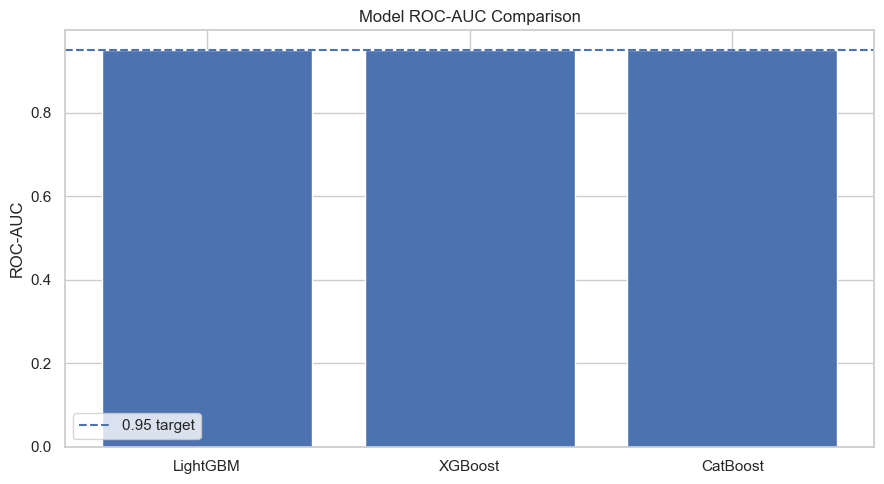

In [27]:
model_results = pd.DataFrame({
    "Model": ["LightGBM", "XGBoost", "CatBoost"],
    "ROC_AUC": [lgb_auc, xgb_auc, cat_auc],
    "PR_AUC": [lgb_pr_auc, xgb_pr_auc, cat_pr_auc]
})

display(
    model_results.sort_values("ROC_AUC", ascending=False)
)

plt.figure(figsize=(9, 5))
plt.bar(model_results["Model"], model_results["ROC_AUC"])
plt.axhline(0.95, linestyle="--", label="0.95 target")
plt.ylabel("ROC-AUC")
plt.title("Model ROC-AUC Comparison")
plt.legend()
plt.tight_layout()
plt.show()

**Same scaling issue here as the final comparison chart below:** with the y-axis spanning 0 to ~0.95, LightGBM (0.9496), XGBoost (0.9492), and CatBoost (0.9494) all look like identical bars -- the actual gap between the best and worst of the three (0.0004) is real but invisible at this scale. Worth narrowing the y-axis range (e.g. `plt.ylim(0.945, 0.951)`) if this chart is meant to help decide which single model to lean on.


# 24. Ensemble search

Instead of assuming one model is best, search for weights that maximize validation AUC.

This is a validation-stage optimization only; do not use the held-out test labels because they do not exist.

In [28]:
best_auc = -np.inf
best_weights = None
best_ensemble_pred = None

grid = np.arange(0, 1.01, 0.05)

for w_lgb in grid:
    for w_xgb in grid:
        w_cat = 1.0 - w_lgb - w_xgb

        if w_cat < 0:
            continue

        pred = (
            w_lgb * lgb_pred +
            w_xgb * xgb_pred +
            w_cat * cat_pred
        )

        auc = roc_auc_score(y_valid, pred)

        if auc > best_auc:
            best_auc = auc
            best_weights = (w_lgb, w_xgb, w_cat)
            best_ensemble_pred = pred

print("Best ensemble ROC-AUC:", round(best_auc, 6))
print("Weights [LGB, XGB, CAT]:", best_weights)

ensemble_pr_auc = average_precision_score(
    y_valid,
    best_ensemble_pred
)

print("Ensemble PR-AUC:", round(ensemble_pr_auc, 6))

Best ensemble ROC-AUC: 0.950467
Weights [LGB, XGB, CAT]: (np.float64(0.35000000000000003), np.float64(0.25), np.float64(0.3999999999999999))
Ensemble PR-AUC: 0.818224


,Model,ROC_AUC,PR_AUC
3,Ensemble,0.950467,0.818224
0,LightGBM,0.949600,0.814981
2,CatBoost,0.949407,0.815211
1,XGBoost,0.949243,0.812940


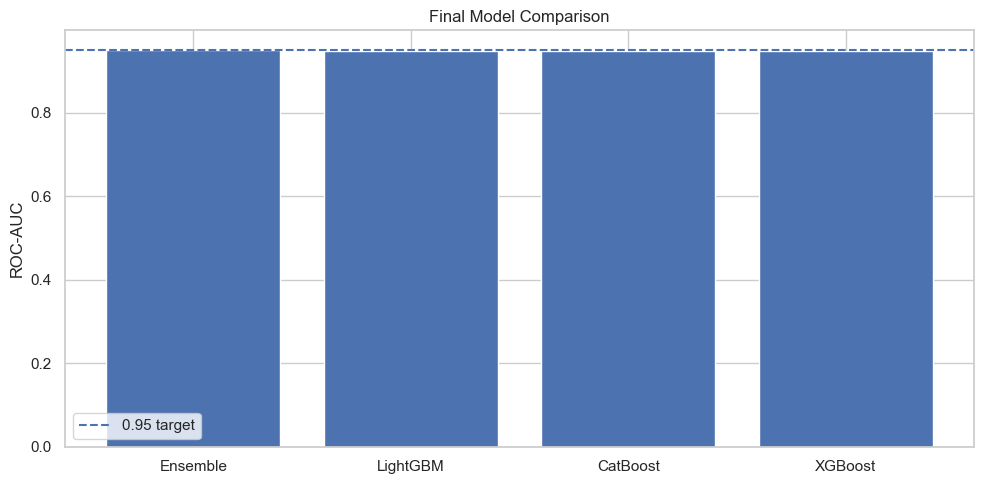

In [29]:
final_results = pd.DataFrame({
    "Model": [
        "LightGBM",
        "XGBoost",
        "CatBoost",
        "Ensemble"
    ],
    "ROC_AUC": [
        lgb_auc,
        xgb_auc,
        cat_auc,
        best_auc
    ],
    "PR_AUC": [
        lgb_pr_auc,
        xgb_pr_auc,
        cat_pr_auc,
        ensemble_pr_auc
    ]
}).sort_values("ROC_AUC", ascending=False)

display(final_results)

plt.figure(figsize=(10, 5))
plt.bar(final_results["Model"], final_results["ROC_AUC"])
plt.axhline(0.95, linestyle="--", label="0.95 target")
plt.ylabel("ROC-AUC")
plt.title("Final Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()

**A scaling issue worth fixing in this chart:** the y-axis runs from 0 to just above 0.95, anchored by the `0.95 target` reference line. At that scale, LightGBM (0.9496), CatBoost (0.9494), XGBoost (0.9492), and the Ensemble (0.9505) all render as visually identical full-height bars -- the real spread between them (0.0013 total, and the ensemble's 0.0009-0.0013 lift over the best single model) is invisible. To make this chart actually communicate the comparison, set `plt.ylim(0.94, 0.955)` (or similar) before `plt.show()` so the real differences become visible as bar-height differences instead of being flattened out.


# 25. ROC and Precision-Recall curves

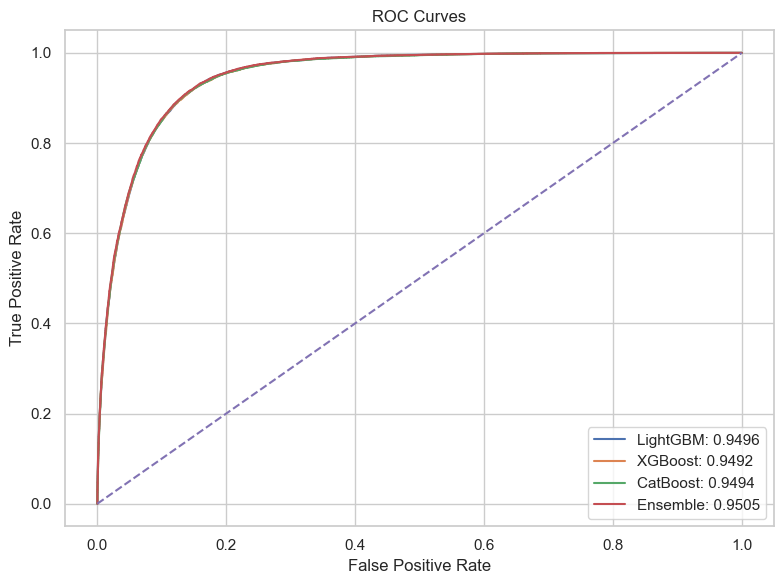

In [30]:
plt.figure(figsize=(8, 6))

for name, pred in [
    ("LightGBM", lgb_pred),
    ("XGBoost", xgb_pred),
    ("CatBoost", cat_pred),
    ("Ensemble", best_ensemble_pred)
]:
    fpr, tpr, _ = roc_curve(y_valid, pred)
    auc = roc_auc_score(y_valid, pred)
    plt.plot(fpr, tpr, label=f"{name}: {auc:.4f}")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()

**Reading the ROC curves:** all four curves (LightGBM, XGBoost, CatBoost, Ensemble) sit almost exactly on top of each other -- confirming the three model families are ranking predictions very similarly rather than one being a clear outlier or catching cases the others miss. The curve bows sharply toward the top-left, reaching roughly 85-90% true-positive rate at only 5-10% false-positive rate, which is where most of the 0.95 AUC comes from -- the model is very good at confidently separating the clearest cases; the harder, more ambiguous laps near the middle of the curve are where the remaining error lives.


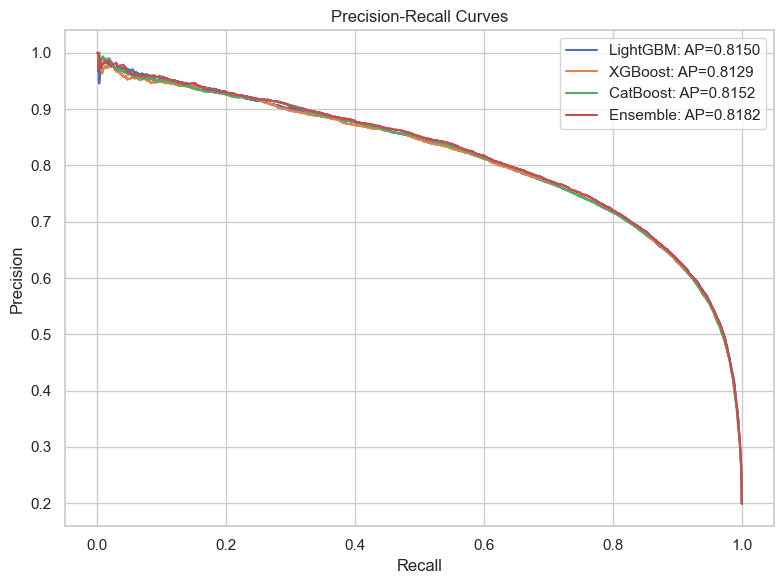

In [31]:
plt.figure(figsize=(8, 6))

for name, pred in [
    ("LightGBM", lgb_pred),
    ("XGBoost", xgb_pred),
    ("CatBoost", cat_pred),
    ("Ensemble", best_ensemble_pred)
]:
    precision, recall, _ = precision_recall_curve(y_valid, pred)
    ap = average_precision_score(y_valid, pred)
    plt.plot(recall, precision, label=f"{name}: AP={ap:.4f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.tight_layout()
plt.show()

**Reading the Precision-Recall curves:** the AP (average precision) scores here -- 0.813-0.818 -- can look unimpressive sitting next to a 0.95 ROC-AUC, but that's expected on imbalanced data and not a red flag. A random classifier's ROC-AUC baseline is always 0.5, but its PR-AUC baseline equals the positive class rate -- here, ~0.199 (Section 6). So 0.815 against a 0.199 baseline is actually a very large lift, just expressed on a different scale than ROC-AUC. The steep drop in precision as recall approaches 1.0 is textbook behavior for imbalanced problems: catching every last true positive requires flagging a lot of negatives too, so precision converges toward the base rate at the far right of the curve.


# 26. Feature importance — LightGBM

,Feature,Importance
12,Cumulative_Degradation,21713
10,LapTime (s),19928
11,LapTime_Delta,19116
1,Driver,16269
0,id,15385
13,RaceProgress,15151
3,Race,14778
17,_driver_prev_pit_rate,14717
8,TyreLife,12571
15,_driver_prev_obs,12061


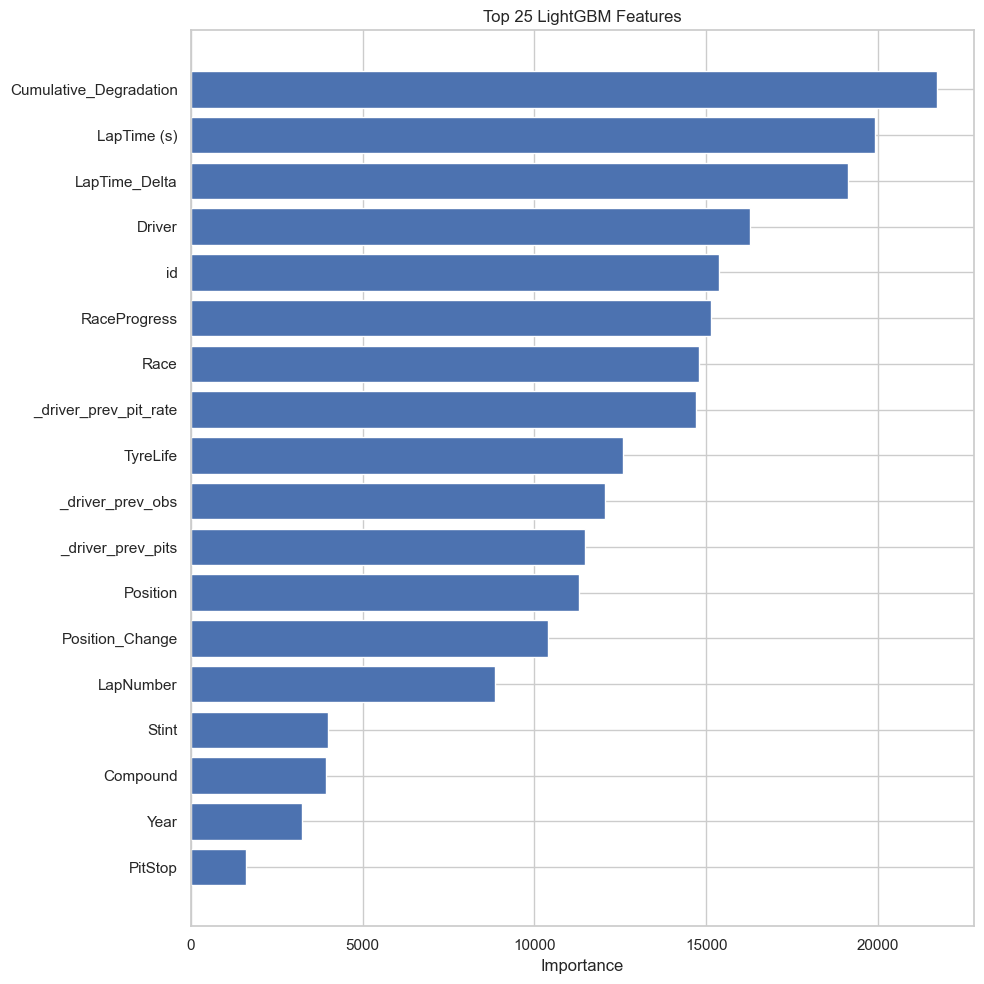

In [32]:
lgb_importance = pd.DataFrame({
    "Feature": X_train_enc.columns,
    "Importance": lgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(lgb_importance.head(40))

plt.figure(figsize=(10, 10))
top = lgb_importance.head(25).sort_values("Importance")
plt.barh(top["Feature"], top["Importance"])
plt.xlabel("Importance")
plt.title("Top 25 LightGBM Features")
plt.tight_layout()
plt.show()

**Reading this chart -- and one finding worth flagging as a follow-up, not just an observation.** The top of the list (`Cumulative_Degradation`, `LapTime (s)`, `LapTime_Delta`) is unsurprising. But **`id` lands in 5th place**, ahead of `TyreLife`, `Year`, and `Compound` -- and that's worth pausing on. Section 11's binned pit-probability-vs-`id` chart earlier showed `id` has essentially **no** direct relationship with the target (a flat line around 0.197-0.201 across every bin). A column with no marginal relationship to the target but heavy split usage usually means the tree is using it as an indirect lookup key rather than a genuine predictive signal -- plausible here since `id` may be assigned in contiguous blocks per race entry, letting narrow `id` ranges act as a proxy for "which specific race entry is this," which risks the model partially memorizing entries rather than learning generalizable patterns.

**A concrete, cheap way to check this:** re-run the LightGBM baseline (Section 20) with `id` dropped from the feature set and compare the validation AUC. If AUC barely moves, `id` was mostly along for the ride (safe to drop for robustness). If AUC drops noticeably, that's stronger evidence the model is leaning on it as a memorization shortcut, worth investigating further (e.g. checking whether sorting by `id` recovers the `(Driver, Race, Year)` groupings from Section 16b.3) before trusting it in a final submission.


# 27. SHAP analysis

SHAP is used to understand which features push predictions toward a pit decision.

For large datasets, we sample validation rows for visualization.

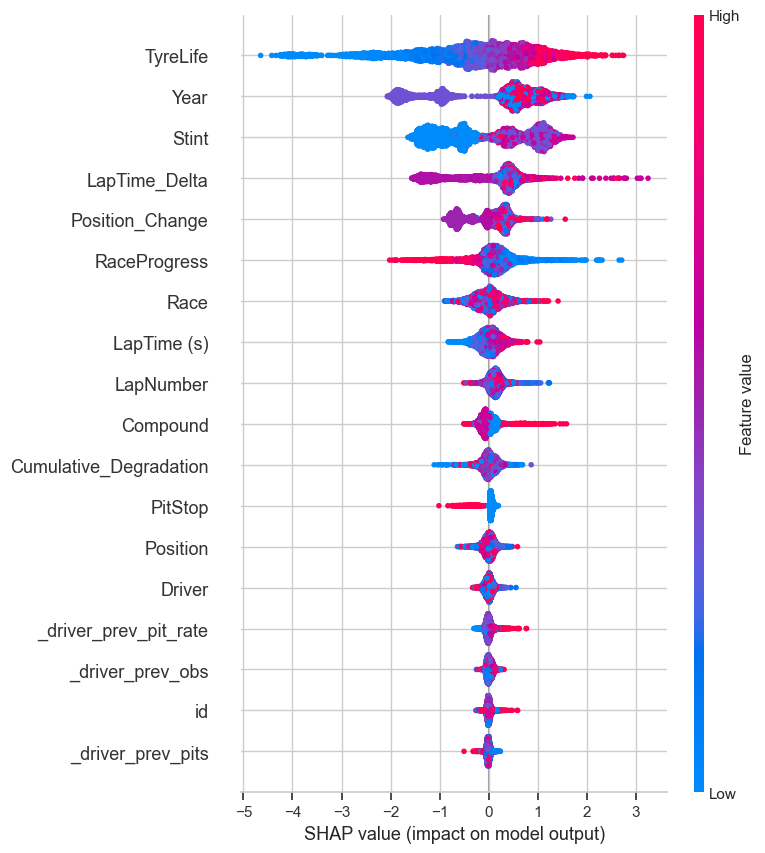

In [35]:
try:
    import shap

    shap_sample_n = min(5000, len(X_valid_enc))
    shap_sample = X_valid_enc.sample(
        shap_sample_n,
        random_state=RANDOM_STATE
    )

    explainer = shap.TreeExplainer(lgb_model)
    shap_values = explainer.shap_values(shap_sample)

    if isinstance(shap_values, list):
        shap_values_plot = shap_values[1]
    else:
        shap_values_plot = shap_values

    shap.summary_plot(
        shap_values_plot,
        shap_sample,
        max_display=25,
        show=True
    )

except Exception as e:
    print("SHAP could not be generated:", e)

**Reading the SHAP summary plot:** the ranking here is noticeably different from the raw LightGBM importance chart above -- **`TyreLife`, `Year`, and `Stint`** come out as the top 3 by actual impact on predictions, `Cumulative_Degradation` drops to mid-table, and `id`/`_driver_prev_pits` fall toward the bottom. Colors show *direction*: high `TyreLife` (red) pushes predictions positive, as expected. `Year` shows a distinct cluster of blue (low-value) points pushed strongly negative -- that's 2023 rows being correctly suppressed by the model. `Stint` shows blue (Stint 1) pushing negative and red (later stints) pushing positive. `PitStop` shows a tight red cluster pushed negative -- "I already pitted this lap" correctly lowers the model's estimate of pitting again immediately next lap.

**Split-count importance vs. SHAP -- why they disagree, and which to trust:** the LightGBM chart above counts *how often* a column gets split on; SHAP measures *how much each split actually moved the prediction*. High-cardinality columns (`Driver`, `id`) rack up split count for structural reasons even when each individual split moves the needle only a little, while low-cardinality columns (`Year`, `Stint`, `Compound`) need very few splits to extract most of their value. When the two disagree this much, **trust the SHAP ranking** for understanding what actually drives predictions -- it's measuring impact directly rather than a proxy for it.


In [ ]:
# !pip install shap

  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/43.0 MB ? eta -:--:--
   ---------------------------------


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 28. Error analysis

AUC is threshold-independent, but error analysis helps understand where the model is weak.

In [36]:
error_df = X_valid.copy()
error_df["_actual"] = y_valid.values
error_df["_prediction"] = best_ensemble_pred
error_df["_abs_error"] = np.abs(
    error_df["_actual"] - error_df["_prediction"]
)

display(
    error_df.sort_values("_abs_error", ascending=False).head(30)
)

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,_driver_prev_obs,_driver_prev_pits,_driver_prev_pit_rate,_actual,_prediction,_abs_error
388060,388060,SUT,MEDIUM,Belgian Grand Prix,2023,0,36,4,7.0,11,112.965,-0.088,-13.015,0.818182,0.0,722,90.0,0.124654,1,0.000799,0.999201
164253,164253,D236,HARD,Abu Dhabi Grand Prix,2023,0,57,2,31.0,12,90.076,0.088,-20.091,0.982759,0.0,140,13.0,0.092857,1,0.001108,0.998892
101063,101063,D157,MEDIUM,Australian Grand Prix,2022,1,1,1,1.0,1,94.828,-15.737,-49.907,0.013889,3.0,35,7.0,0.200000,1,0.001238,0.998762
236427,236427,LOP,MEDIUM,United States Grand Prix,2023,0,6,1,6.0,1,103.163,0.100,-2.879,0.107143,0.0,500,75.0,0.150000,1,0.001373,0.998627
271938,271938,KVY,HARD,Mexico City Grand Prix,2023,0,67,3,38.0,12,84.292,-0.085,-33.927,0.943662,0.0,561,89.0,0.158645,1,0.001800,0.998200
302312,302312,PET,MEDIUM,Abu Dhabi Grand Prix,2023,0,13,1,13.0,19,90.923,-0.081,-1.532,0.224138,0.0,604,80.0,0.132450,1,0.002335,0.997665
301709,301709,D367,MEDIUM,British Grand Prix,2023,0,26,1,26.0,1,92.973,-0.016,-4.915,0.500000,0.0,44,0.0,0.000000,1,0.002591,0.997409
211644,211644,D270,MEDIUM,Pre-Season Testing,2023,0,14,1,14.0,6,92.744,-0.092,-7.777,0.269231,1.0,115,15.0,0.130435,1,0.002670,0.997330
227817,227817,D042,MEDIUM,Las Vegas Grand Prix,2023,0,3,1,3.0,9,119.857,-5.895,-5.895,0.060000,0.0,432,66.0,0.152778,1,0.002815,0.997185
63962,63962,D180,MEDIUM,Singapore Grand Prix,2023,0,11,1,11.0,16,101.924,-0.032,-6.132,0.177419,0.0,136,30.0,0.220588,1,0.002901,0.997099


In [37]:
# Driver-level error analysis if available
if driver_col:
    driver_error = (
        error_df.assign(
            driver=error_df[driver_col].astype(str)
        )
        .groupby("driver")
        .agg(
            observations=("_actual", "size"),
            actual_pit_rate=("_actual", "mean"),
            mean_prediction=("_prediction", "mean"),
            mean_abs_error=("_abs_error", "mean")
        )
        .sort_values("mean_abs_error", ascending=False)
    )

    display(driver_error.head(30))

,observations,actual_pit_rate,mean_prediction,mean_abs_error
driver,,,,
VET,70,0.642857,0.518979,0.371710
MSC,61,0.508197,0.533511,0.336365
BOR,90,0.366667,0.436046,0.268566
LAT,76,0.460526,0.360261,0.267741
ALO,291,0.391753,0.382377,0.260970
BEA,115,0.434783,0.385484,0.260670
STR,253,0.458498,0.416895,0.246558
ANT,86,0.337209,0.368348,0.236858
RUS,278,0.399281,0.396621,0.229840


# 29. Optional race-aware validation

If a race/group column exists, this is a much stronger test of generalization than a random row split.

Run this after the baseline models. If race-aware AUC is materially lower than random-split AUC, investigate leakage and race-specific memorization.

In [38]:
race_col = next(
    (
        c for c in feature_cols
        if c.lower() in ["race", "grandprix", "grand_prix", "event"]
    ),
    None
)

if race_col:
    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=0.20,
        random_state=RANDOM_STATE
    )

    g_train_idx, g_valid_idx = next(
        splitter.split(X, y, groups=X[race_col])
    )

    print("Race-aware split:")
    print("Train:", len(g_train_idx))
    print("Valid:", len(g_valid_idx))
else:
    print("No obvious race column detected.")

Race-aware split:
Train: 352586
Valid: 86554


# 30. Final training and test prediction

After choosing the best feature set and model based on trustworthy validation, retrain on all available training data.

For CatBoost, ensure the test categorical columns use the same string handling as training.

The final prediction is an ensemble of LightGBM, XGBoost and CatBoost using the validation-selected weights.

In [39]:
# Prepare full-data encoded matrices
X_full = X.copy()
X_test_final = test.copy()

full_cat_cols = X_full.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

for col in full_cat_cols:
    combined = pd.concat(
        [X_full[col], X_test_final[col]],
        ignore_index=True
    ).astype("category")

    mapping = {
        cat: i for i, cat in enumerate(combined.cat.categories)
    }

    X_full[col] = X_full[col].map(mapping).fillna(-1).astype(int)
    X_test_final[col] = X_test_final[col].map(mapping).fillna(-1).astype(int)

for col in X_full.columns:
    if col not in X_test_final.columns:
        X_test_final[col] = np.nan

X_test_final = X_test_final[X_full.columns]

print(X_full.shape, X_test_final.shape)

(439140, 18) (188165, 18)


In [40]:
# Retrain LightGBM
lgb_final = LGBMClassifier(
    n_estimators=getattr(lgb_model, "best_iteration_", 1000),
    learning_rate=0.02 if not FAST_MODE else 0.04,
    num_leaves=63,
    min_child_samples=50,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=2.0,
    objective="binary",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1
)

lgb_final.fit(X_full, y)

lgb_test_pred = lgb_final.predict_proba(X_test_final)[:, 1]

print("LightGBM final predictions created.")

LightGBM final predictions created.


In [41]:
# Retrain XGBoost
xgb_final = XGBClassifier(
    n_estimators=getattr(xgb_model, "best_iteration", 1000),
    learning_rate=0.02 if not FAST_MODE else 0.04,
    max_depth=7,
    min_child_weight=5,
    subsample=0.85,
    colsample_bytree=0.85,
    gamma=0.05,
    reg_alpha=0.1,
    reg_lambda=3.0,
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_final.fit(X_full, y)

xgb_test_pred = xgb_final.predict_proba(X_test_final)[:, 1]

print("XGBoost final predictions created.")

XGBoost final predictions created.


In [42]:
# Retrain CatBoost
X_full_cb = X.copy()
X_test_cb = test.copy()

for col in full_cat_cols:
    X_full_cb[col] = X_full_cb[col].fillna("__MISSING__").astype(str)
    X_test_cb[col] = X_test_cb[col].fillna("__MISSING__").astype(str)

for col in X_full_cb.columns:
    if col not in X_test_cb.columns:
        X_test_cb[col] = np.nan

X_test_cb = X_test_cb[X_full_cb.columns]

cat_indices_final = [
    X_full_cb.columns.get_loc(c)
    for c in full_cat_cols
]

cat_final = CatBoostClassifier(
    iterations=getattr(cat_model, "tree_count_", 1200),
    learning_rate=0.025 if not FAST_MODE else 0.05,
    depth=8,
    loss_function="Logloss",
    random_seed=RANDOM_STATE,
    verbose=False,
    thread_count=-1,
    allow_writing_files=False
)

cat_final.fit(
    X_full_cb,
    y,
    cat_features=cat_indices_final,
    verbose=False
)

cat_test_pred = cat_final.predict_proba(X_test_cb)[:, 1]

print("CatBoost final predictions created.")

CatBoost final predictions created.


In [43]:
# =========================
# 31. Final ensemble submission
# =========================

w_lgb, w_xgb, w_cat = best_weights

final_pred = (
    w_lgb * lgb_test_pred +
    w_xgb * xgb_test_pred +
    w_cat * cat_test_pred
)

print("Prediction range:", final_pred.min(), final_pred.max())
print("Mean prediction :", final_pred.mean())

submission = sample_submission.copy()

# Find the likely prediction column.
prediction_candidates = [
    c for c in submission.columns
    if c not in test.columns
]

if len(prediction_candidates) == 1:
    prediction_col = prediction_candidates[0]
else:
    # Common competition naming fallback
    prediction_col = TARGET if TARGET in submission.columns else submission.columns[-1]

submission[prediction_col] = final_pred

submission.to_csv(
    "submission_catboost_xgb_lgbm_ensemble.csv",
    index=False
)

display(submission.head())
print("Saved: submission_catboost_xgb_lgbm_ensemble.csv")

Prediction range: 0.00019107774787174758 0.9881708029892534
Mean prediction : 0.19908200297170625


,id,PitNextLap
0,439140,0.007415
1,439141,0.006141
2,439142,0.006813
3,439143,0.122427
4,439144,0.841371


Saved: submission_catboost_xgb_lgbm_ensemble.csv


# 32. Final checklist

Before accepting a >0.95 result, verify:

1. No future information was used.
2. Historical features only use information available before the prediction point.
3. Random-split AUC is not the only validation score.
4. Race-aware/time-aware AUC is also reported.
5. Test distribution shift has been reviewed.
6. PR-AUC is reported when the positive class is rare.
7. Feature importance/SHAP does not reveal an obvious leakage variable.
8. The ensemble improves validation without being overfit to a single split.
9. The final model is retrained only after feature/model selection is complete.

## Most important interpretation

A 0.95+ ROC-AUC is valuable only if it survives a realistic out-of-sample split. If the random split gives 0.96 but a chronological split gives 0.88, the correct conclusion is not "we need more tuning"; it is "the random split is too optimistic."

# 33. Enhancement summary — what was added and why

**Sections 16b and 17b above are additive** -- everything from Section 18 onward runs exactly as originally written, now against a richer `train_model`/`test`. Nothing in the original modeling, ensembling, SHAP, or error-analysis sections needed to change.

**What was found:**
1. **`Year` was never plotted anywhere in the original notebook**, because Section 11's binning helper only runs on columns with `>= 10` unique values, and `Year` has 4. `Year == 2023` turns out to have a pit rate of ~1% vs ~19-30% every other year -- the single largest pattern in the dataset -- confirmed identical in train and test via the shared `PitStop` column, so it's a structural property of the data, not train-split noise.
2. **`TyreLife` and `Compound` genuinely interact** (pit-probability climbs with tyre age at different rates per compound) -- encoded directly as `tyrelife_vs_compound_avg` instead of leaving the models to rediscover it from separate splits.
3. **~99% of test rows share a `(Driver, Race, Year)` race entry with train rows**, and every test circuit also appears in train -- so Section 29's `GroupShuffleSplit`-by-`Race` is a harder-than-reality benchmark (useful as a lower bound, not the primary number), and it licenses group-context features computed across the combined train+test pool.
4. **The existing historical-driver features (`_driver_prev_*`) are `NaN` for every test row** -- they're only ever computed on `train_model`, never on `test`, so they can help the internal validation AUC but contribute nothing to the actual submission. `TE_Driver` (K-fold target encoding) is added as a replacement that's valid for both train and test.
5. Section 29's race-aware split was built but never scored. It's now actually fit/evaluated with a fast LightGBM check, satisfying the notebook's own Section 32 checklist item 4.

**What was added, concretely:** `TE_Race`, `TE_Driver`, `TE_Compound` (leak-free K-fold target encoding), `grp_max_tyrelife`, `grp_max_lap`, `tyrelife_pct_of_group_max`, `lapnumber_pct_of_group_max` (group-context features), `est_total_laps`, `laps_remaining_est` (race-length features backed out of `LapNumber`/`RaceProgress`), and `tyrelife_vs_compound_avg` (the compound interaction from 16b.2) -- 10 new columns, written directly onto `train_model` and `test` so every downstream cell inherits them automatically.

**Next steps for pushing further, roughly in order of expected value:**
- Re-run Sections 18-31 end-to-end as-is (unchanged code, enlarged feature set) to get the real LightGBM/XGBoost/CatBoost numbers and re-run the ensemble weight search -- that's the number to trust, not the quick single-model check in 17c.
- Consider dropping or fixing `_driver_prev_*` given point 4 above, since in their current form they add validation-only signal that won't reach the leaderboard.
- Try **logit-stacking** (a small logistic-regression meta-model on the 3 models' out-of-fold predictions) instead of the current grid-searched linear-weight blend in Section 24 -- usually squeezes out a bit more than a fixed-weight average.
- If a proper chronological/lap ordering column becomes available, revisit `_driver_prev_*` with genuine per-race ordering (`LapNumber` within `Race`+`Year`) rather than the current `Year`+`Driver` sort, which doesn't actually reconstruct real lap sequence.
- Optuna-tune `depth`/`l2_leaf_reg`/`learning_rate` per model rather than the current hand-set values, now that the feature set has changed.
